# EsT Objective Extensions: End-of-Gate Transparency and Drive Shape

*Companion to `est_experiments.ipynb`, the replication of Roy, Wetherbee & Fatemi, arXiv:2603.15356.
That notebook trains the paper's objective and reports where it falls short; this one changes the
objective. Both sections were §11 and §12 there and were moved here unchanged apart from numbering.*

Everything here runs on the eigh + hand-derived-adjoint pipeline of
[est_experiments §8](est_experiments.ipynb#8) and starts from that notebook's baselines: the ten-seed screen of
[est_experiments §9](est_experiments.ipynb#9) and the full-budget `best2000` pulses of
[est_experiments §9.2](est_experiments.ipynb#9.2).

| section | gate | question |
|---|---|---|
| [§1](#1) | X | The X pulses are transparent on average but leak at $t = T$ ([est_experiments limitation 3](est_experiments.ipynb#10)). Which extra cost term closes the endpoint leak, and what does it cost elsewhere? |
| [§2](#2) | T | T's stage 2 puts 35% of the transmon drive energy into the closing 48 ns. Does keeping $C_3$, or adding $C_6$, in stage 2 even the drive out? |

**Reading note.** Sections, tables and figures restart at 1. Figure and table *files* keep their
original names (`figures/est/fig6*_newterms_*`, `figures/est/fig7*_stage2_*`,
`tables/est_newterms_*`, `tables/est_stage2_T_*`), because `EST/compare_new_terms.py`,
`EST/smoke_new_terms.py` and `EST/stage2_t.py` write them. Each section studies one gate, and its
full-budget runs are a single seed.

## Preamble: imports and knobs

In [1]:
import os
import sys

REPO_ROOT = os.path.abspath(".")
if REPO_ROOT not in sys.path:
    sys.path.insert(0, REPO_ROOT)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import Image, display

from EST import device, kitten_code

# --- knobs ---
REGENERATE_FIGURES = True   # recompute the §1 / §2 tables (EST/compare_new_terms.py, EST/stage2_t.py)
N_C                = 20     # scoring truncation; the trained one
# -------------

PULSE_DIR = os.path.join(REPO_ROOT, "pulses", "est")
FIG_DIR   = os.path.join(REPO_ROOT, "figures", "est")
TABLE_DIR = os.path.join(REPO_ROOT, "tables")
LOG_DIR   = os.path.join(REPO_ROOT, "logs")

# Figures are SAVED and then displayed with IPython.display.Image rather than with
# display(fig): EST/diagnostics and EST/subspace_evolution call matplotlib.use("Agg")
# internally, so an inline-rendered figure would depend on cell execution order.
def show(path, width=900):
    display(Image(filename=path, width=width))

pd.set_option("display.width", 200)
pd.set_option("display.max_columns", 40)
print("repo root:", REPO_ROOT)

repo root: /Users/ziyi_dong_mac/Documents/GitHub/Qubit-Drive-GRAPE


<a id="1"></a>
# 1. Extra cost terms for end-of-gate transparency

The X pulses of [est_experiments §5](est_experiments.ipynb#5) and [est_experiments §9.2](est_experiments.ipynb#9.2) are transparent on average but not at the end. The
[est_experiments §9.2](est_experiments.ipynb#9.2) pulse (seed 6) finishes at $L(T) = 0.398$, against $0.013$ in the paper
([est_experiments limitation 3](est_experiments.ipynb#10)). QEC runs at $t = T$, so the endpoint is the number that matters. The
objective explains the gap. $C_1$ is terminal on the code space, but nothing is terminal on the
error space: $C_2$ is a time average. App. C of the paper (p. 14) lists extra cost terms that
"can be employed in the same framework". This section adds three, trains X with each, and asks
two questions: which term closes the endpoint leak, and what does it cost elsewhere?

<a id="1.1"></a>
### 1.1 Method

**Three terms**, added on top of $C_1$–$C_4$ in the eigh + hand-derived-adjoint pipeline of
[est_experiments §8](est_experiments.ipynb#8) (`EST/grape_eigh.py`):

| term | definition | type | weight (both stages) |
|---|---|---|---|
| $C_{\rm err}$ | $1-\frac16\sum_j \lvert\langle U_{\rm ideal}E_j \mid U(T) \mid \psi_{E_j}\rangle\rvert^2$: $C_1$ applied to the error cardinals | terminal | $w_{\rm err} = 0.3$ |
| $C_5$ | $\big\langle \big(\Delta\bar n_L(t)/(\bar n_0+\bar n_1)\big)^2 \big\rangle_t$, with $\Delta\bar n_L$ from Eq. A7 | running | $w_5 = 30$ |
| $C_6$ | $\sum_k \lVert u_{k+1}-u_k\rVert^2$, the cat-code smoothness penalty | pulse | $w_6 = 5\times10^{-6}$ (half the cat-code value) |

**Table 1. The extra cost terms.** Each term keeps its weight in both stages; $C_1$–$C_4$ keep
the [est_experiments §2.5](est_experiments.ipynb#2.5) schedule (Table 1b). $1 - C_{\rm err}$ on `u_X_est` is $0.589$, the error-basis overlap
quoted in [est_experiments limitation 3](est_experiments.ipynb#10), so $C_{\rm err}$ trains exactly the quantity that limitation reports.
The $[0,1]$ normalization of $C_5$ is this repo's choice; the paper gives none.

**Weights in each stage.** Every run minimizes $C = \sum_i w_i C_i$ in two L-BFGS-B stages. The
weights $w_i$ play the role of the penalty $\lambda$'s in the cat-code track. Each tuple below is
$(w_1, w_2, w_3, w_4;\ w_{\rm err}, w_5, w_6)$, the weights on
$(C_1, C_2, C_3, C_4;\ C_{\rm err}, C_5, C_6)$:

| run | iterations per stage | stage 1 | stage 2 |
|---|---|---|---|
| baseline (`est_best2000`, [est_experiments §9.2](est_experiments.ipynb#9.2)) | 2000 | $(1,\ 0.7,\ 7,\ 1;\ 0,\ 0,\ 0)$ | $(1,\ 0.1,\ 0,\ 1;\ 0,\ 0,\ 0)$ |
| `est_err` | 2000 | $(1,\ 0.7,\ 7,\ 1;\ \mathbf{0.3},\ 0,\ 0)$ | $(1,\ 0.1,\ 0,\ 1;\ \mathbf{0.3},\ 0,\ 0)$ |
| `est_dn` | 2000 | $(1,\ 0.7,\ 7,\ 1;\ 0,\ \mathbf{30},\ 0)$ | $(1,\ 0.1,\ 0,\ 1;\ 0,\ \mathbf{30},\ 0)$ |
| `est_err_dn` | 2000 | $(1,\ 0.7,\ 7,\ 1;\ \mathbf{0.3},\ \mathbf{30},\ 0)$ | $(1,\ 0.1,\ 0,\ 1;\ \mathbf{0.3},\ \mathbf{30},\ 0)$ |
| `est_all` | 2000 | $(1,\ 0.7,\ 7,\ 1;\ \mathbf{0.3},\ \mathbf{30},\ \mathbf{5\times10^{-6}})$ | $(1,\ 0.1,\ 0,\ 1;\ \mathbf{0.3},\ \mathbf{30},\ \mathbf{5\times10^{-6}})$ |
| scan control ([est_experiments §9](est_experiments.ipynb#9) screen, each seed) | 500 | $(1,\ 0.7,\ 7,\ 1;\ 0,\ 0,\ 0)$ | $(1,\ 0.1,\ 0,\ 1;\ 0,\ 0,\ 0)$ |
| scan, $C_{\rm err}$ alone | 500 | $(1,\ 0.7,\ 7,\ 1;\ \mathbf{w_{\rm err}},\ 0,\ 0)$ | $(1,\ 0.1,\ 0,\ 1;\ \mathbf{w_{\rm err}},\ 0,\ 0)$, $\ w_{\rm err} \in \{0.3, 1, 3\}$ |
| scan, $C_5$ alone | 500 | $(1,\ 0.7,\ 7,\ 1;\ 0,\ \mathbf{w_5},\ 0)$ | $(1,\ 0.1,\ 0,\ 1;\ 0,\ \mathbf{w_5},\ 0)$, $\ w_5 \in \{1, 3, 6, 10, 15, 30\}$ |

**Table 1b. Objective weights per stage.** The full-run rows are read from each run's
`logs/est_X_<run>.json` sidecar, and the scan rows from `logs/est_X_est_{err,dn}_smoke500_seed<s>_w*.json`
(seed 6's cells from the original scan: `..._smoke500_w*.json`). Every scan row is run at
each of the six seeds.
Bold marks the weights this section adds. Only $w_2$ and $w_3$ change between stages:
- **Stage 1** trains transparency: $w_2 = 0.7$ on $C_2$ and $w_3 = 7$ on $C_3$.
- **Stage 2** finishes the gate: $w_2$ drops to $0.1$ and $w_3$ to $0$.

The extra weights $w_{\rm err}$, $w_5$ and $w_6$ are the same in both stages. $w_1 = w_4 = 1$
throughout. `est_all`'s $w_6$ is `DEFAULT_W_SMOOTH` in `EST/train_est_eigh.py`; the command below
passes no `--w-smooth`.

Two properties of $C_5$ matter below:
- **It is necessary, not sufficient.** It constrains only the $Z$ part of the $(a,a)$ term of
  $\Delta_{\rm QEC}$.
- **It is small** ($\sim10^{-2}$), because a linear drive shifts $\bar n_0$ and $\bar n_1$
  equally and only the nonlinearities separate them. That is why its weight is large.

**Correctness.** The three hand-derived gradients agree with central finite differences and
with JAX autodiff to a relative $10^{-8}$ (`EST/test_grape_eigh.py`, 34 tests). With the extra
weights at zero, the objective is bit-identical to before.

**Protocol.**
1. **Weight scan** (Figure 1a). X, 500 it/stage, over the six seeds of [est_experiments §9](est_experiments.ipynb#9) that reach a
   gate: 0, 2, 4, 5, 6 and 8 (seeds 1, 3, 7 and 9 park, [est_experiments Table 15](est_experiments.ipynb#9)). $w_{\rm err} \in \{0.3, 1, 3\}$
   and $w_5 \in \{1, 3, 6, 10, 15, 30\}$, each term alone: 54 runs. Each seed's control is its
   own [est_experiments §9](est_experiments.ipynb#9) screen pulse, at the same budget. The scan was first run at seed 6 alone with
   $w_5 \in \{3, 10, 30, 100\}$; seed 6 reuses those runs where the weight is still on the grid,
   and $w_5 = 100$ has left it.
2. **Selection.** Take the largest weight that still reaches the gate ($c_1 \le 3\times$ the
   control's), improves its own target, and costs at most $0.05$ in $F_{\rm ET}$. **The last
   condition was added after the seed-6 scan.** Without it, that scan's rule picked
   $w_{\rm err} = 3$ and $w_5 = 100$, which damage transparency. Over six seeds, the gate condition
   must hold on every seed against its own control, and the other two compare seed means.
3. **Training.** Four cold starts at seed 6, 2000 it/stage, with the same pipeline and the same
   $C_1$–$C_4$ weights per stage as the [est_experiments §9.2](est_experiments.ipynb#9.2) baseline (Table 1b): `est_err` (+ $C_{\rm err}$), `est_dn` (+ $C_5$), `est_err_dn` (both) and
   `est_all` (both + $C_6$).

```
python EST/smoke_new_terms.py commands > scan.sh && sh scan.sh   # the six-seed scan, 6 jobs at a time
python EST/smoke_new_terms.py summarize   # -> tables/est_newterms_smoke_X_6seeds.csv

for v in est_err est_dn est_err_dn est_all; do
  OMP_NUM_THREADS=2 python EST/train_est_eigh.py --gate X --variant $v --seed 6 \
      --maxiter 2000 --w-err 0.3 --w-dn 30 --tag seed6 &
done; wait
python EST/compare_new_terms.py    # scores every pulse -> tables/est_newterms_X_seed6*
```

In [2]:
# §1 setup, then Figure 1a. Encoding shared by Figures 1a-c: the baseline in near-black and
# the four runs in categorical slots 1-4 (fixed order), each with its own line style, so no
# run is identified by colour alone.
from matplotlib.lines import Line2D
from matplotlib.ticker import FormatStrFormatter, NullFormatter
import importlib
from EST import kitten_code, grape_eigh, train_est_eigh, compare_new_terms as cnt
from EST import smoke_new_terms as snt

# Sections 8 and 9 already imported these modules (via compare_propagators and
# multiseed_est). A kernel that ran them before the extra cost terms existed keeps the
# stale copies, and cnt.main() then fails with "build_gate_objective() got an
# unexpected keyword argument 'extra_terms'". Reload in dependency order:
# train_est_eigh binds build_gate_objective by name, so it must follow grape_eigh.
for _mod in (kitten_code, grape_eigh, train_est_eigh, cnt, snt):
    importlib.reload(_mod)

NT_RUNS = ["baseline", "est_err", "est_dn", "est_err_dn", "est_all"]
NT_LABEL = {"baseline": "baseline (est_experiments §9.2)", "est_err": r"+ $C_{\rm err}$",
            "est_dn": r"+ $C_5$", "est_err_dn": r"+ $C_{\rm err}$ + $C_5$",
            "est_all": r"+ $C_{\rm err}$ + $C_5$ + $C_6$"}
NT_COLOR = {"baseline": "#1f1f1f", "est_err": "#2a78d6", "est_dn": "#eb6834",
            "est_err_dn": "#1baf7a", "est_all": "#eda100"}
NT_LS = {"baseline": "-", "est_err": "-", "est_dn": "--", "est_err_dn": "-.", "est_all": ":"}
# The 500-it scan over the six est_experiments §9 seeds that reach a gate. The seed-6-only scan it
# replaced stays frozen in tables/est_newterms_smoke_X_seed6.csv.
NT_SCAN_CSV = snt.CSV_PATH
NT_CHOSEN = {"err": 0.3, "dn": 30.0}      # the weights the §1.2 full runs use

nt_missing = [v for v in NT_RUNS[1:]
              if not os.path.exists(os.path.join(PULSE_DIR, f"u_X_{v}_seed6.npy"))]
nt_have = not nt_missing
nt_scan_have = os.path.exists(NT_SCAN_CSV)
if not nt_have:
    print("§1.2 full runs missing; generate with:")
    for v in NT_RUNS[1:]:
        print(f"  OMP_NUM_THREADS=2 python EST/train_est_eigh.py --gate X --variant {v} "
              "--seed 6 --maxiter 2000 --w-err 0.3 --w-dn 30 --tag seed6")
    print("  python EST/compare_new_terms.py")
if not nt_scan_have:
    print("§1.1 six-seed weight scan missing; generate with:")
    print("  python EST/smoke_new_terms.py commands > scan.sh && sh scan.sh")
    print("  python EST/smoke_new_terms.py summarize")

if nt_have:
    if REGENERATE_FIGURES or not (os.path.exists(cnt.CSV_PATH)
                                  and os.path.exists(cnt.TRACES_PATH)):
        cnt.main()
    nt = pd.read_csv(cnt.CSV_PATH)
    ntr = np.load(cnt.TRACES_PATH)

if nt_scan_have:
    scan = pd.read_csv(NT_SCAN_CSV)
    scan_ctrl = scan[scan.term == "control"]
    # The selection rule re-applied to the six-seed scan (seed means, gate on every seed).
    _, scan_pick, scan_pick_rev = snt.apply_rule(scan)

    SCAN_METRICS = [("L_T", r"$L(T)$   (lower is better)"),
                    ("F_ET", r"$F_{\rm ET}$   (higher is better)"),
                    ("delta_qec_mean", r"mean $\Delta_{\rm QEC}$   (lower is better)"),
                    ("eta0_mean", r"mean $\eta(|0_L\rangle)$   (lower is better)")]
    SCAN_ROWS = [("err", "est_err", r"$C_{\rm err}$ alone", r"weight $w_{\rm err}$"),
                 ("dn", "est_dn", r"$C_5$ alone", r"weight $w_5$")]
    # (pick, marker, size, edge colour, line width): full-run weight, then both rules.
    MARKS = lambda term: [(NT_CHOSEN[term], "o", 260, "k", 1.8),
                          (scan_pick[term], "s", 170, "0.45", 1.4),
                          (scan_pick_rev[term], "D", 120, "#b0197e", 1.4)]

    fig, axes = plt.subplots(2, 4, figsize=(16.0, 6.6))
    jit = np.random.default_rng(0)
    for r, (term, run, row_name, wlab) in enumerate(SCAN_ROWS):
        d = scan[scan.term == term].sort_values(["weight", "seed"])
        grid = np.sort(d.weight.unique())
        # Same multiplicative jitter in every column, so one seed sits at the same x.
        xj = d.weight.to_numpy() * 10 ** jit.uniform(-0.03, 0.03, len(d))
        for c, (col, title) in enumerate(SCAN_METRICS):
            ax = axes[r, c]
            ax.axhspan(scan_ctrl[col].min(), scan_ctrl[col].max(), color="0.55",
                       alpha=0.14, lw=0, zorder=0)
            ax.axhline(scan_ctrl[col].mean(), color="0.55", ls="--", lw=1.4, zorder=1)
            ax.scatter(xj, d[col], s=18, color=NT_COLOR[run], alpha=0.35, lw=0, zorder=2)
            mean = d.groupby("weight")[col].mean()
            ax.plot(mean.index, mean.values, color=NT_COLOR[run], lw=2, marker="o", ms=7,
                    zorder=3)
            for w, mk, size, ec, lw in MARKS(term):
                if w is not None and w in mean.index:
                    ax.scatter([w], [mean[w]], s=size, marker=mk, facecolors="none",
                               edgecolors=ec, linewidths=lw, zorder=4)
            ax.set_xscale("log")
            ax.set_xticks(grid)
            ax.xaxis.set_major_formatter(FormatStrFormatter("%g"))
            ax.xaxis.set_minor_formatter(NullFormatter())
            ax.set_xlabel(wlab)
            ax.grid(alpha=0.25)
            if r == 0:
                ax.set_title(title, fontsize=10)
        axes[r, 0].set_ylabel(row_name, fontsize=11)

    handles = [Line2D([], [], color="0.3", lw=2, marker="o", ms=6, label="seed mean"),
               Line2D([], [], ls="", marker="o", ms=5, color="0.3", alpha=0.35,
                      label="individual seeds"),
               Line2D([], [], color="0.55", ls="--", lw=1.4,
                      label="control mean (band: min-max over seeds)"),
               Line2D([], [], ls="", marker="o", ms=13, mfc="none", mec="k", mew=1.8,
                      label="weight used for the full runs"),
               Line2D([], [], ls="", marker="s", ms=10, mfc="none", mec="0.45", mew=1.4,
                      label="pick of the original rule"),
               Line2D([], [], ls="", marker="D", ms=8, mfc="none", mec="#b0197e", mew=1.4,
                      label="pick of the revised rule")]
    fig.legend(handles=handles, loc="lower center", ncol=6, frameon=False, fontsize=9,
               bbox_to_anchor=(0.5, -0.03))
    fig.suptitle("Figure 1a. Weight scan: X gate, seeds "
                 + ", ".join(str(s) for s in snt.SEEDS) + ", 500 it/stage", fontsize=11)
    fig.tight_layout(rect=(0, 0.04, 1, 0.96))
    fig6a_path = os.path.join(FIG_DIR, "fig6a_newterms_scan_X.png")
    fig.savefig(fig6a_path, dpi=160, bbox_inches="tight")
    plt.close(fig)
    show(fig6a_path, width=1100)
    print("six-seed picks  original rule:", scan_pick, "  revised rule:", scan_pick_rev)

§1.1 six-seed weight scan missing; generate with:
  python EST/smoke_new_terms.py commands > scan.sh && sh scan.sh
  python EST/smoke_new_terms.py summarize


**Figure 1a. Weight scan (X, seeds 0, 2, 4, 5, 6, 8, 500 it/stage).** Top row: $C_{\rm err}$
alone. Bottom row: $C_5$ alone. The columns are leakage at the end of the gate $L(T)$,
time-averaged transparency $F_{\rm ET}$, time-averaged $\Delta_{\rm QEC}$, and the time-averaged
trajectory mismatch $\eta(|0_L\rangle)$ of Eq. 8. Faint dots are individual seeds and the bold
line is their mean. The dashed line is the mean of the six controls with no extra terms, and the
grey band spans them. The ring marks the weight used for the full runs; the square and diamond
mark the original and revised rules' picks on this scan, both applied to seed means.

> **Pending re-run.** The bullets below still quote the original seed-6-only scan
> (`tables/est_newterms_smoke_X_seed6.csv`) and will be rewritten from the six-seed table.

- **$C_{\rm err}$ removes the endpoint leak at the smallest weight** ($L(T)$
  $0.549 \to 0.011$). Larger weights gain nothing at $t = T$ and cost $F_{\rm ET}$
  ($0.687 \to 0.445$).
- **$C_5$ lowers $\Delta_{\rm QEC}$** ($0.289 \to 0.147$ at $w_5 = 30$) but never lowers $L(T)$.
  At $w_5 = 100$ it raises $L(T)$ to $0.845$.

<a id="1.2"></a>
### 1.2 Results

The comparison has five pulses: the [est_experiments §9.2](est_experiments.ipynb#9.2) baseline and the four runs. All share seed, budget
(2000 it/stage, every stage stopped on `maxiter`) and pipeline. All are scored the same way: the
training report at $n_c = 20$, and Eqs. 6–8 through the independent eigh propagator.

In [3]:
# Table 2: scalar metrics, final pulses first, then the stage-1 pulses.
if nt_have:
    T19_COLS = ["run", "stage", "F1", "F_ET", "F_err_T", "L_mean", "L_tail", "L_T",
                "dqec_mean", "eta0_mean", "eta0_tail", "c6", "oob_max", "max_active_fock"]
    t19 = (nt.assign(_run=nt.run.map({r: i for i, r in enumerate(NT_RUNS)}),
                     _stage=(nt.stage == "stage1"))
             .sort_values(["_stage", "_run"])[T19_COLS])
    display(t19.style.format({
        "F1": "{:.5f}", "F_ET": "{:.3f}", "F_err_T": "{:.3f}", "L_mean": "{:.3f}",
        "L_tail": "{:.3f}", "L_T": "{:.4f}", "dqec_mean": "{:.3f}", "eta0_mean": "{:.3f}",
        "eta0_tail": "{:.3f}", "c6": "{:.0f}", "oob_max": "{:.1e}"}, na_rep="-")
        .hide(axis="index"))

run,stage,F1,F_ET,F_err_T,L_mean,L_tail,L_T,dqec_mean,eta0_mean,eta0_tail,c6,oob_max,max_active_fock
baseline,final,0.99910,0.744,0.538,0.244,0.408,0.3976,0.356,0.138,0.449,12596,2.3e-03,11
est_err,final,0.99950,0.750,0.996,0.231,0.048,0.0049,0.217,0.221,0.045,11059,4.3e-03,9
est_dn,final,0.99909,0.718,0.337,0.269,0.566,0.5886,0.181,0.174,0.679,11451,2.1e-03,13
est_err_dn,final,0.99708,0.602,0.982,0.379,0.137,0.0219,0.275,0.299,0.131,12822,4.2e-03,11
est_all,final,0.99774,0.614,0.982,0.312,0.093,0.0277,0.248,0.534,0.018,2395,2.1e-04,9
baseline,stage1,0.94426,0.782,0.366,0.207,0.457,0.4779,0.424,0.159,0.648,13940,-,10
est_err,stage1,0.97439,0.739,0.932,0.246,0.198,0.1175,0.138,0.222,0.077,12169,-,9
est_dn,stage1,0.96952,0.707,0.326,0.281,0.512,0.5614,0.174,0.197,0.303,11015,-,10
est_err_dn,stage1,0.97176,0.701,0.843,0.289,0.296,0.2034,0.234,0.189,0.461,16937,-,9
est_all,stage1,0.97539,0.688,0.883,0.274,0.209,0.1596,0.227,0.351,0.169,5411,-,9


**Table 2. Scalar metrics for the final and stage-1 pulses.** The "tail" columns average over
$t \ge 0.9\,T$. `oob_max` is the larger out-of-band energy fraction of the two drives, audited
on final pulses only. For every pulse, the re-scored $F_1$ matches the training cost to
$10^{-14}$, and the held-out-truncation spread is at most $2.4\times10^{-4}$.

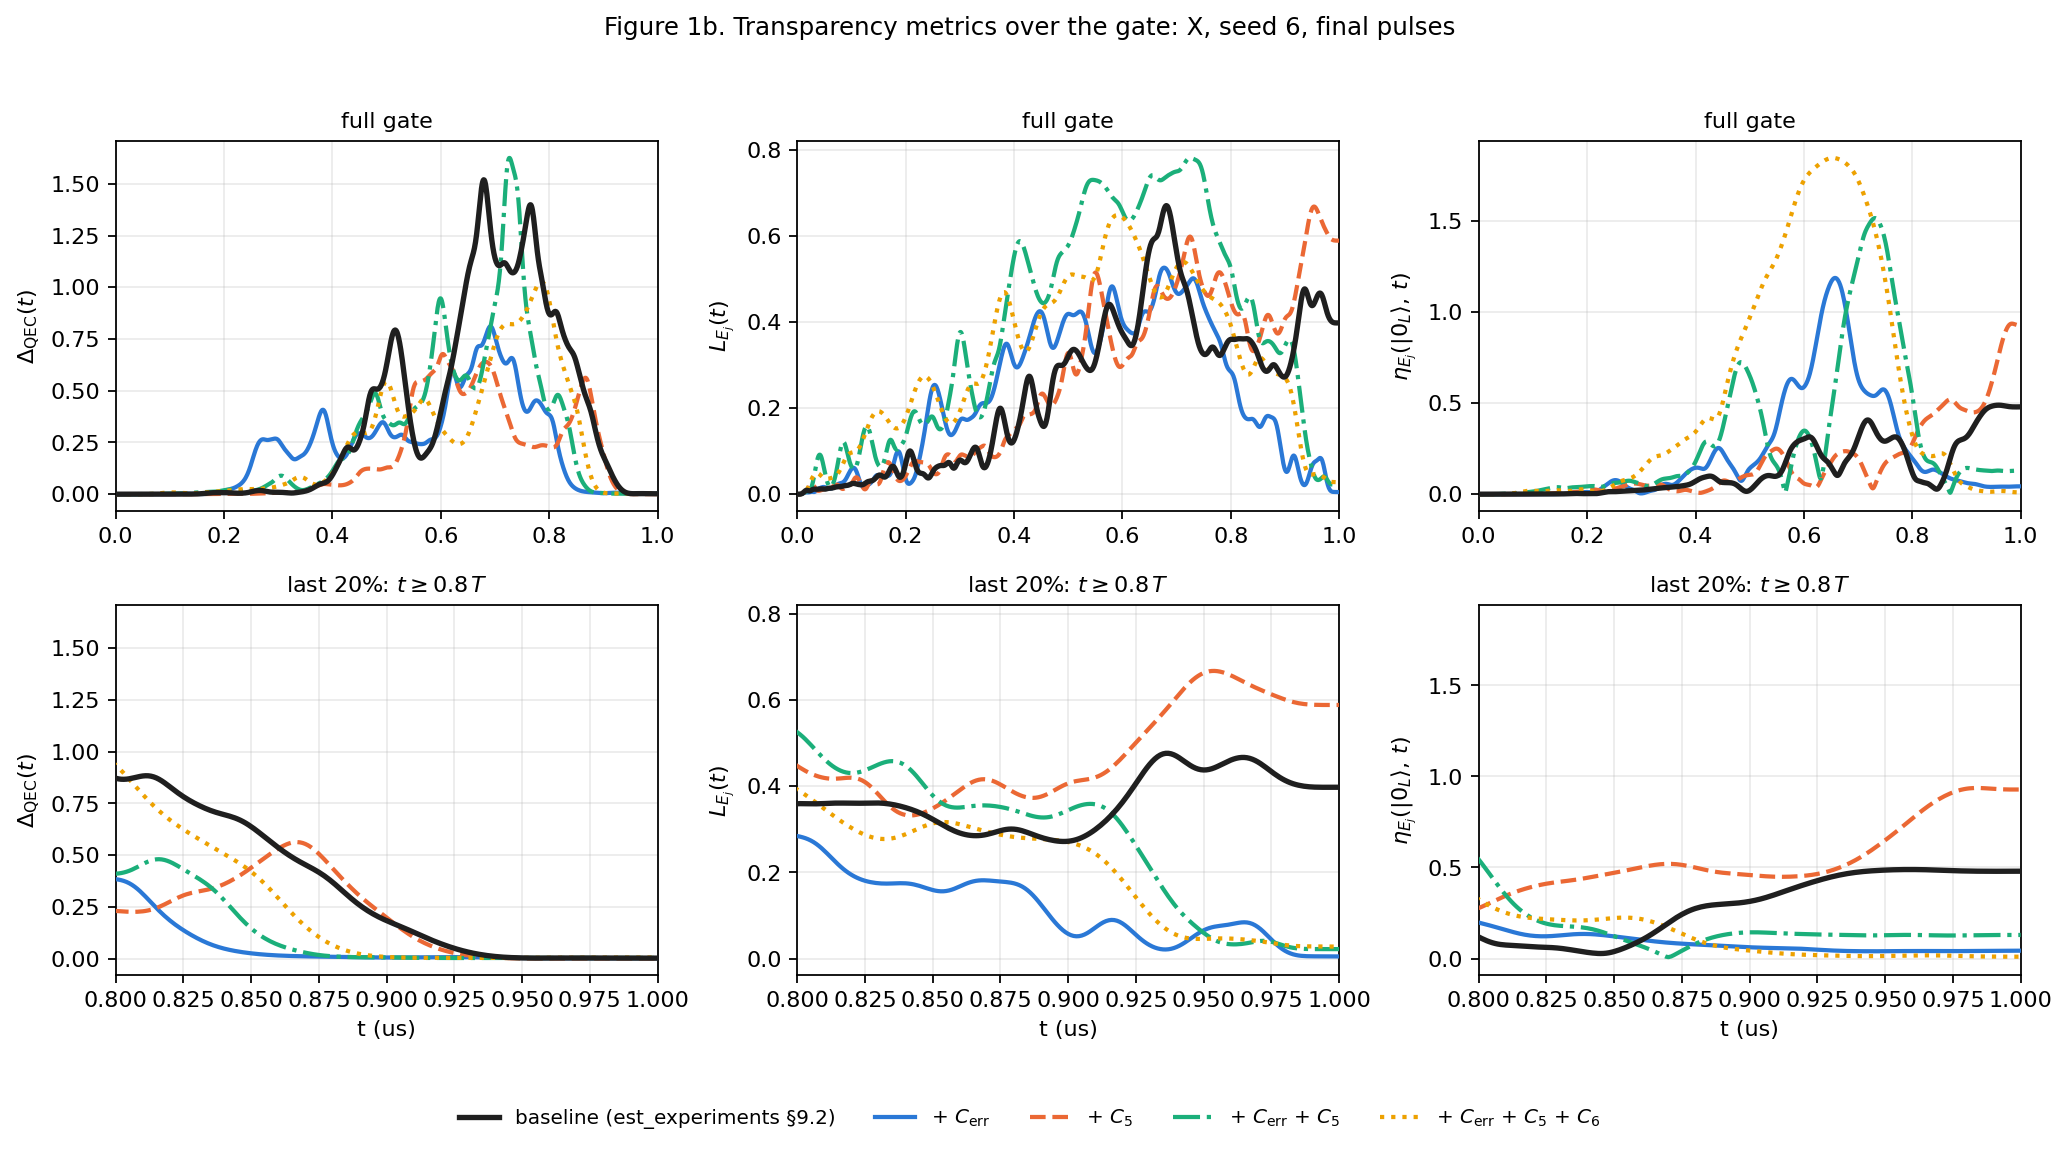

In [4]:
# Figure 1b: Eqs. 6-8 over the gate for the five final pulses; bottom row zooms to the end.
if nt_have:
    TR_COLS = [("dqec", r"$\Delta_{\rm QEC}(t)$"), ("L", r"$L_{E_j}(t)$"),
               ("eta0", r"$\eta_{E_j}(|0_L\rangle,\,t)$")]
    fig, axes = plt.subplots(2, 3, figsize=(13.0, 7.0), sharey="col")
    for c, (key, ylab) in enumerate(TR_COLS):
        for r in range(2):
            ax = axes[r, c]
            for run in NT_RUNS:
                t = ntr[f"{run}/final/t"]
                base = run == "baseline"
                ax.plot(t, ntr[f"{run}/final/{key}"], color=NT_COLOR[run], ls=NT_LS[run],
                        lw=2.4 if base else 1.9, zorder=4 if base else 3,
                        label=NT_LABEL[run])
            T = t[-1]
            ax.set_xlim((0.0 if r == 0 else 0.8 * T), T)
            ax.set_ylabel(ylab)
            ax.grid(alpha=0.25)
            ax.set_title(("full gate" if r == 0 else r"last 20%: $t \geq 0.8\,T$"), fontsize=10)
            if r == 1:
                ax.set_xlabel("t (us)")
    handles, labels = axes[0, 0].get_legend_handles_labels()
    fig.legend(handles, labels, loc="lower center", ncol=5, frameon=False, fontsize=9,
               bbox_to_anchor=(0.5, -0.03))
    fig.suptitle("Figure 1b. Transparency metrics over the gate: X, seed 6, final pulses",
                 fontsize=11)
    fig.tight_layout(rect=(0, 0.04, 1, 0.96))
    fig6b_path = os.path.join(FIG_DIR, "fig6b_newterms_traces_X.png")
    fig.savefig(fig6b_path, dpi=160, bbox_inches="tight")
    plt.close(fig)
    show(fig6b_path, width=980)

**Figure 1b. The three transparency metrics of Eqs. 6–8 over the gate, final pulses.**
Columns: $\Delta_{\rm QEC}(t)$, $L_{E_j}(t)$ and $\eta_{E_j}(|0_L\rangle, t)$. Top row: the full
1 us gate. Bottom row: its last 20%. The metrics and propagator are the same as in est_experiments Figures 2 and 5.

1. **$C_{\rm err}$ fixes the endpoint.** Every run that contains it (blue, green, yellow) drives
   $L$ toward zero over the last 100 ns. `est_err` ends at $L(T) = 0.005$, against $0.398$ for
   the baseline and $0.013$ in the paper. $\eta(|0_L\rangle)$ follows at the end (tail $0.046$
   against $0.450$), but mid-gate it shows larger excursions than the baseline.
2. **$C_5$ acts mid-gate, not at the end.** `est_dn` (orange) lowers the $\Delta_{\rm QEC}$ peak
   but ends with more leakage than the baseline, $L(T) = 0.589$.
3. **The terms do not add.** `est_err_dn` keeps the endpoint gain ($L(T) = 0.022$) but leaks
   more mid-gate than either term alone: mean $L$ is $0.379$, against $0.231$ and $0.269$.

$\Delta_{\rm QEC}$ reaching zero at $t = T$ for every pulse is the artifact noted in [est_experiments §5](est_experiments.ipynb#5):
a gate that lands on the code words has no Knill–Laflamme violation there.

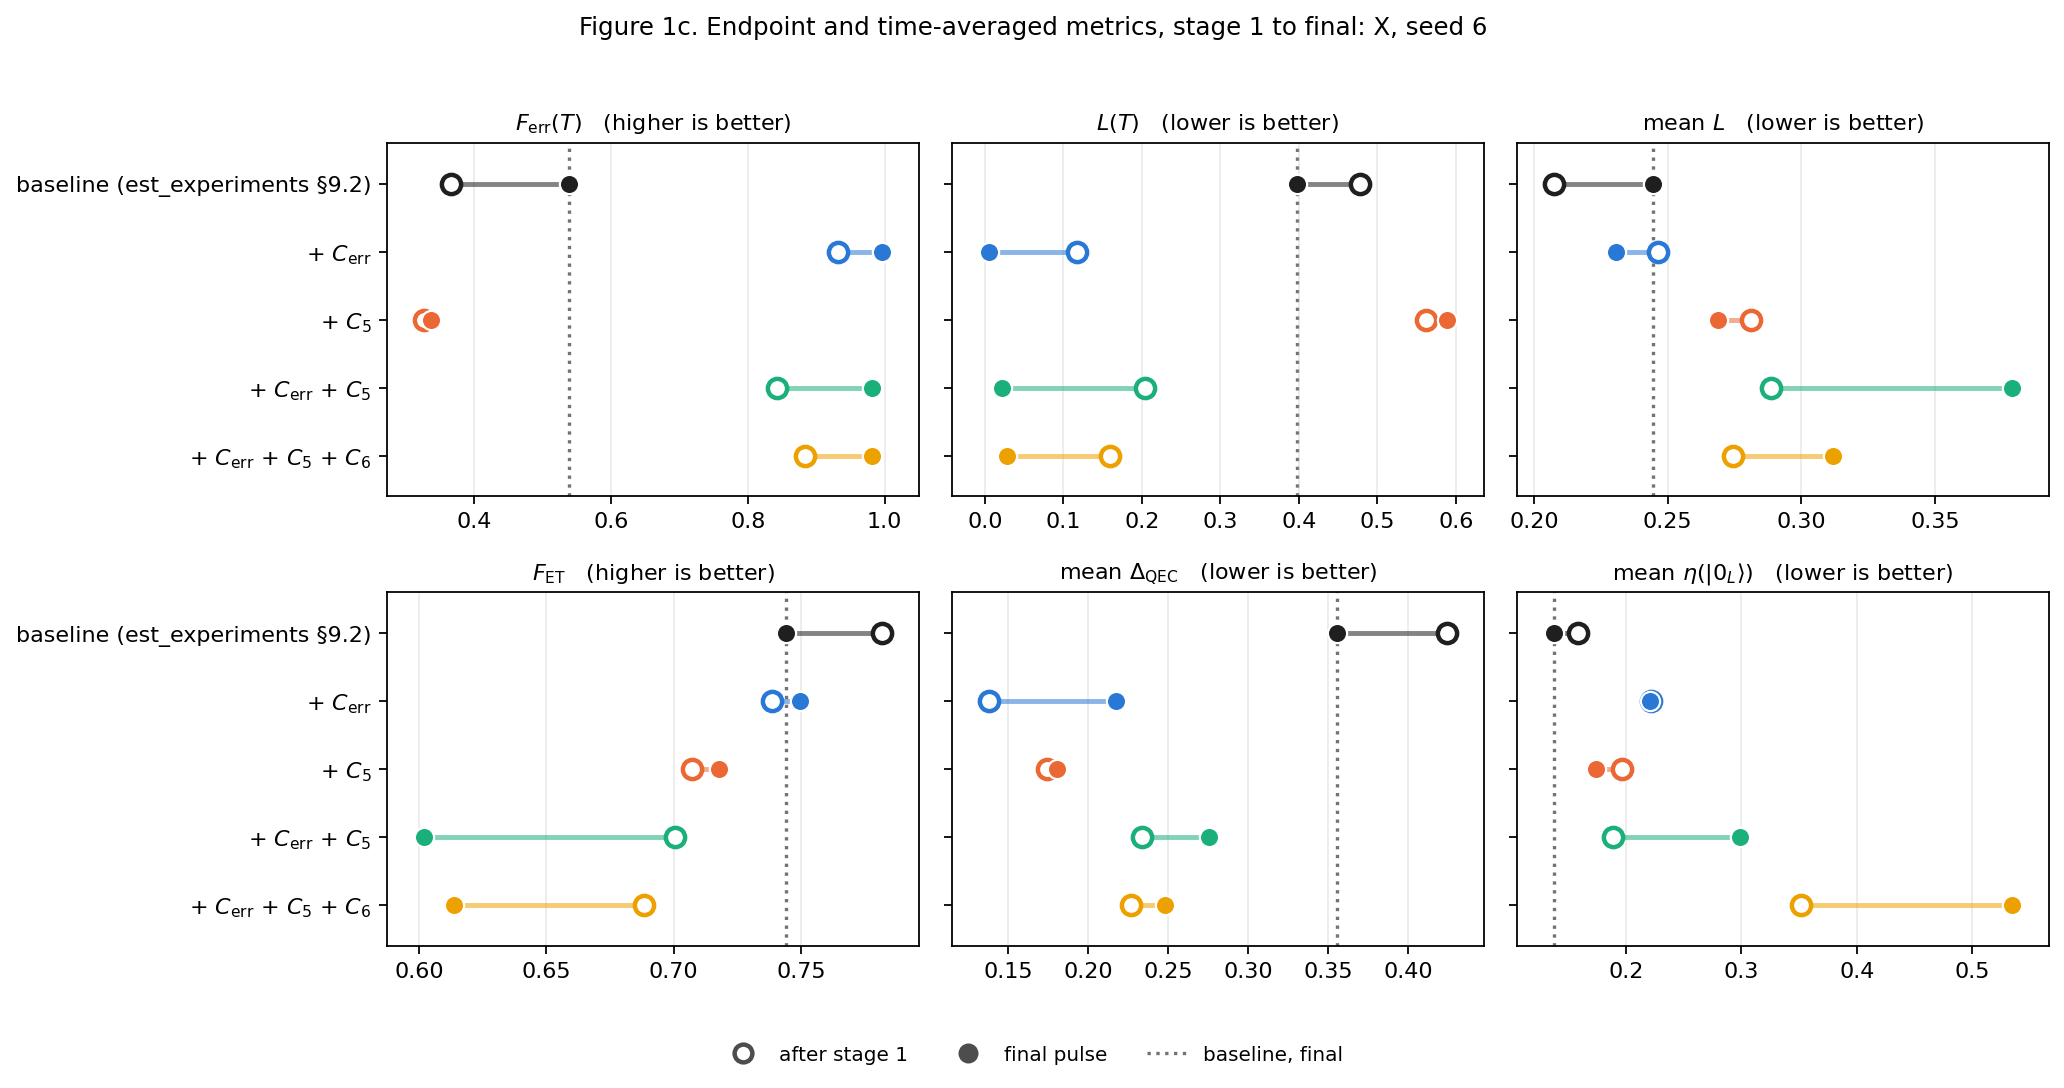

In [5]:
# Figure 1c: endpoint and time-averaged metrics per run, stage 1 (hollow) -> final (filled).
if nt_have:
    DB = [("F_err_T", r"$F_{\rm err}(T)$", "higher"), ("L_T", r"$L(T)$", "lower"),
          ("L_mean", r"mean $L$", "lower"), ("F_ET", r"$F_{\rm ET}$", "higher"),
          ("dqec_mean", r"mean $\Delta_{\rm QEC}$", "lower"),
          ("eta0_mean", r"mean $\eta(|0_L\rangle)$", "lower")]
    ypos = {run: i for i, run in enumerate(reversed(NT_RUNS))}      # baseline on top
    val = lambda run, stage, col: float(nt.loc[(nt.run == run) & (nt.stage == stage), col].iloc[0])

    fig, axes = plt.subplots(2, 3, figsize=(13.0, 6.6), sharey=True)
    for ax, (col, name, better) in zip(axes.ravel(), DB):
        ax.axvline(val("baseline", "final", col), color="0.45", ls=":", lw=1.5, zorder=1)
        for run in NT_RUNS:
            s1, s2, y = val(run, "stage1", col), val(run, "final", col), ypos[run]
            ax.plot([s1, s2], [y, y], color=NT_COLOR[run], lw=2.2, alpha=0.55, zorder=2)
            ax.scatter([s1], [y], s=75, facecolors="white", edgecolors=NT_COLOR[run],
                       linewidths=2.0, zorder=3)
            ax.scatter([s2], [y], s=75, color=NT_COLOR[run], edgecolors="white",
                       linewidths=1.0, zorder=4)
        ax.set_title(f"{name}   ({better} is better)", fontsize=10)
        ax.set_yticks(list(ypos.values()))
        ax.set_yticklabels([NT_LABEL[run] for run in ypos])
        ax.set_ylim(-0.6, len(NT_RUNS) - 0.4)
        ax.margins(x=0.08)
        ax.grid(alpha=0.25, axis="x")
    handles = [Line2D([], [], ls="", marker="o", ms=8, mfc="white", mec="0.3", mew=2,
                      label="after stage 1"),
               Line2D([], [], ls="", marker="o", ms=8, color="0.3", label="final pulse"),
               Line2D([], [], color="0.45", ls=":", lw=1.5, label="baseline, final")]
    fig.legend(handles=handles, loc="lower center", ncol=3, frameon=False, fontsize=9,
               bbox_to_anchor=(0.5, -0.03))
    fig.suptitle("Figure 1c. Endpoint and time-averaged metrics, stage 1 to final: X, seed 6",
                 fontsize=11)
    fig.tight_layout(rect=(0, 0.04, 1, 0.96))
    fig6c_path = os.path.join(FIG_DIR, "fig6c_newterms_summary_X.png")
    fig.savefig(fig6c_path, dpi=160, bbox_inches="tight")
    plt.close(fig)
    show(fig6c_path, width=980)

**Figure 1c. Endpoint and time-averaged metrics for every run.** Each panel is one metric.
A hollow marker is the pulse after stage 1, a filled marker the final pulse. The dotted line is
the baseline's final value.

`est_err` is the only run that beats the baseline at the endpoint without losing on the
averages:

| | $F_{\rm err}(T)$ | $L(T)$ | $F_{\rm ET}$ | mean $L$ | mean $\Delta_{\rm QEC}$ |
|---|---|---|---|---|---|
| `est_err` | $0.996$ | $0.005$ | $0.750$ | $0.231$ | $0.217$ |
| baseline | $0.538$ | $0.398$ | $0.744$ | $0.245$ | $0.356$ |

Its one loss is time-averaged $\eta(|0_L\rangle)$: $0.221$ against $0.138$. That metric is
where every added term costs something, and $C_6$ costs the most (`est_all`: $0.534$).

**Stage 2 differs by run.** In the baseline, stage 2 spends transparency to buy $F_1$
($F_{\rm ET}$ $0.782 \to 0.744$). In `est_err`, the terminal term holds the error trajectory,
and stage 2 improves both $F_{\rm ET}$ ($0.739 \to 0.750$) and $L(T)$ ($0.118 \to 0.005$). The
two combined runs lose $F_{\rm ET}$ in stage 2 ($0.70 \to 0.60$ and $0.69 \to 0.61$).

<a id="1.3"></a>
### 1.3 Final drive waveforms

Figures 1b–c score what the five final pulses do to the state. This subsection compares the
pulses themselves: the $I$ and $Q$ quadratures of the cavity and transmon drives, as delivered
(after the band limit, ramp and control mask). The drive magnitude $\sqrt{I^2+Q^2}$ is left out;
est_experiments Figure 3 and Figure 2a show it for other pulses.

**All five runs start from the same pre-image.** Seed 6 fixes the cold-start draw
(`EST/train_est_eigh.py`), so only the objective differs between runs.

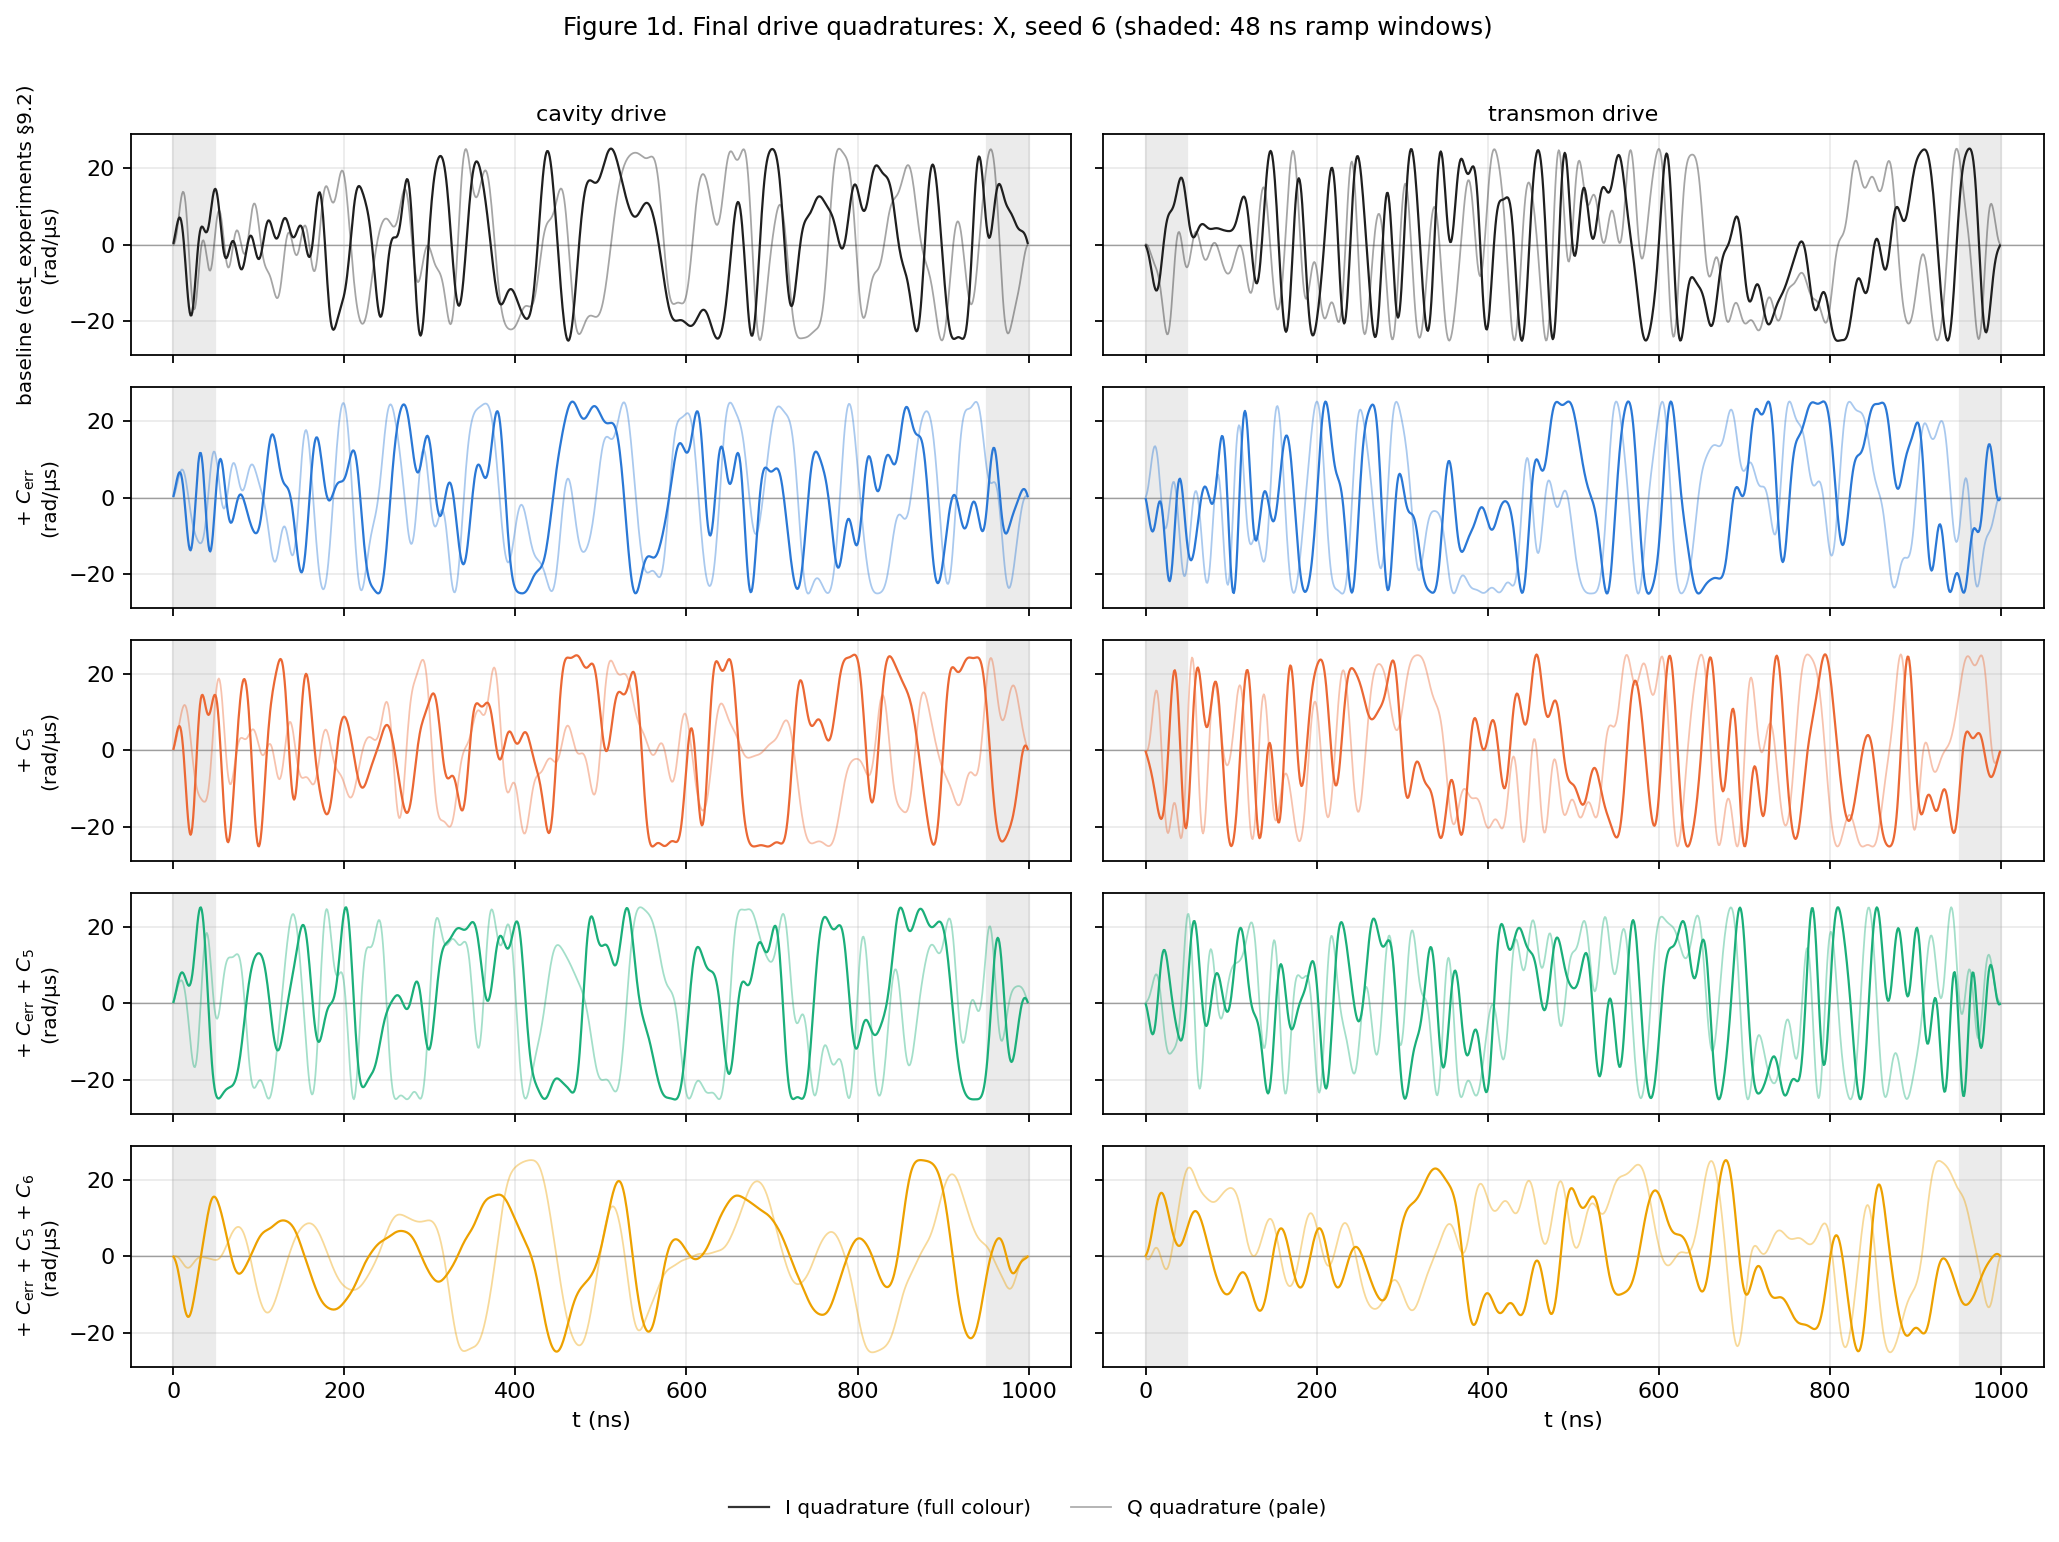

In [6]:
# Figure 1d: the I and Q quadratures of both drives for the five final pulses, one row per run.
# The drive magnitude is deliberately not drawn (est_experiments Figure 3 and Figure 2a show it); this is the waveform.
if nt_have:
    NT_U = {run: np.load(os.path.join(PULSE_DIR, f"u_X_{stem}.npy")) for run, stem in cnt.RUNS}
    NT_DRIVES = [(0, "cavity"), (2, "transmon")]

    fig, axes = plt.subplots(len(NT_RUNS), 2, figsize=(13.0, 1.9 * len(NT_RUNS)),
                             sharex=True, sharey=True, squeeze=False)
    for r, run in enumerate(NT_RUNS):
        u = NT_U[run]
        N = len(u)
        t_ns = np.arange(N) * device.DT * 1e3
        T_ns = N * device.DT * 1e3
        for c, (lo, name) in enumerate(NT_DRIVES):
            ax = axes[r, c]
            for x0, x1 in ((0.0, device.RAMP_NS), (T_ns - device.RAMP_NS, T_ns)):
                ax.axvspan(x0, x1, color="0.92", zorder=0)
            ax.axhline(0, color="0.6", lw=0.6, zorder=1)
            ax.plot(t_ns, u[:, lo], color=NT_COLOR[run], lw=1.0, zorder=3)
            ax.plot(t_ns, u[:, lo + 1], color=NT_COLOR[run], lw=0.8, alpha=0.4, zorder=2)
            ax.set_ylim(-1.15 * device.EPS_MAX, 1.15 * device.EPS_MAX)
            ax.grid(alpha=0.25)
            if r == 0:
                ax.set_title(f"{name} drive", fontsize=10)
            if c == 0:
                ax.set_ylabel(NT_LABEL[run] + "\n(rad/μs)", fontsize=9)
    for ax in axes[-1]:
        ax.set_xlabel("t (ns)")
    handles = [Line2D([], [], color="0.2", lw=1.0, label="I quadrature (full colour)"),
               Line2D([], [], color="0.2", lw=0.8, alpha=0.4, label="Q quadrature (pale)")]
    fig.legend(handles=handles, loc="lower center", ncol=2, frameon=False, fontsize=9,
               bbox_to_anchor=(0.5, -0.02))
    fig.suptitle("Figure 1d. Final drive quadratures: X, seed 6 "
                 f"(shaded: {device.RAMP_NS:.0f} ns ramp windows)", fontsize=11)
    fig.tight_layout(rect=(0, 0.03, 1, 0.97))
    fig6d_path = os.path.join(FIG_DIR, "fig6d_newterms_quadratures_X.png")
    fig.savefig(fig6d_path, dpi=160, bbox_inches="tight")
    plt.close(fig)
    show(fig6d_path, width=980)

**Figure 1d. Delivered drive quadratures of the five final pulses.** Rows: runs, in Table 2's
order. Columns: cavity drive, transmon drive. Full colour: $I$; pale: $Q$. All panels share axes;
shading marks the 48 ns ramp windows.

- **Every run uses the full amplitude range.** Each quadrature of every pulse reaches
  $\pm 25$ rad/μs, the $C_4$ cap.
- **Four of the five waveforms are alike in character but not in detail.** The baseline,
  `est_err`, `est_dn` and `est_err_dn` are fast, near-bang-bang waveforms, with 26–46 zero
  crossings of $I$ per gate. Their shapes do not line up.
- **$C_6$ is the only term that visibly changes the waveform.** `est_all` crosses zero 20 times on
  each drive. Its rms step between samples, $|\varepsilon_{k+1}-\varepsilon_k|$, is 2.3–2.4x smaller than
  `est_err_dn`'s, the same run without $C_6$ (cavity $0.92$ against $2.19$ rad/μs; transmon $1.25$
  against $2.84$).

<a id="1.4"></a>
### 1.4 Conclusion and caveats

**The endpoint leak of [est_experiments limitation 3](est_experiments.ipynb#10) is a gap in the objective, not a limit of the device.** One
terminal error-space term ($w_{\rm err} = 0.3$) takes X's $L(T)$ from $0.398$ to $0.005$. Over
the same change, $F_1$ ($0.9995$), $F_{\rm ET}$ ($0.750$) and $\Delta_{\rm QEC}$ ($0.217$) hold
or improve. The other two terms do different jobs:
- **$C_5$ reduces $\Delta_{\rm QEC}$, not leakage.**
- **$C_6$ smooths the pulse, at a cost in $\eta$.** Adding it to `est_err_dn` lowers $C_6$
  5.4x and out-of-band energy from $4.2\times10^{-3}$ to $2.1\times10^{-4}$. $F_{\rm ET}$, mean
  $L$ and mean $\Delta_{\rm QEC}$ improve slightly, but mean $\eta(|0_L\rangle)$ worsens from
  $0.299$ to $0.534$.

Caveats:
- **One seed, one gate, for the full runs.** The 500-it scan of Figure 1a covers six seeds; the
  2000-it runs of §1.2 are seed 6 only. $F_{\rm ET}$ differences below the [est_experiments §9](est_experiments.ipynb#9) seed sd ($0.028$)
  are not results; the 80x change in $L(T)$ is.
- **The weights are ballparks.** They were chosen from a single-seed 500-it scan by a rule
  revised after seeing it. The six-seed scan of Figure 1a checks that choice; the full runs were
  not retrained from it. The two terms were never scanned jointly.
- **$L$ here is closed-system and lossless.** It is not the paper's master-equation ET fidelity
  ([est_experiments limitation 1](est_experiments.ipynb#10)).
- **Every pulse, the baseline included, ends with its raw pre-image at `hard_bound` = 60.** The
  physical amplitude cap ($C_4$) holds.
- **Not yet run:** an `ord` control at seed 6, the H and T gates, and more seeds.

<a id="2"></a>
# 2. Evening out the T-gate drive: stage-2 $C_3$ and $C_6$

est_experiments Figure 3c's T pulse finishes the gate at the very end. On [est_experiments §9.2](est_experiments.ipynb#9.2)'s `u_T_est_best2000` (eigh, seed 1,
2000 it/stage), **35% of the transmon drive energy falls in the closing 48 ns ramp window**, the
peak $|\varepsilon_T| = 25.1$ rad/μs sits at $t = 584$ ns, and fidelity to the target is only
$0.912$ when that window opens. Its stage-1 pulse had 9% there. The end-loading is made in
**stage 2**, the stage that drops $w_3$ to 0.

<a id="2.1"></a>
### 2.1 Method

Three stage-2-only changes (`STAGE2_VARIANTS` in `EST/train_est_eigh.py`). Stage 1 is `est`'s
stage 1 in every run, so at the same seed it is the same stage 1, and [est_experiments §9.2](est_experiments.ipynb#9.2)'s run is the control:

| run | stage 1 $(w_1,w_2,w_3,w_4)$ | stage 2 $(w_1,w_2,w_3,w_4;\,w_6)$ |
|---|---|---|
| control (`est_best2000`) | $(1, 0.7, 7, 1)$ | $(1, 0.1, \mathbf{0}, 1;\ 0)$ |
| `est_c3s2` | same | $(1, 0.1, \mathbf{7}, 1;\ 0)$ |
| `est_d2` | same | $(1, 0.1, 0, 1;\ \mathbf{w_6})$ |
| `est_c3s2_d2` | same | $(1, 0.1, \mathbf{7}, 1;\ \mathbf{w_6})$ |

**Table 3a. The runs.** T gate, seed 1, cold start, 2000 it/stage, eigh + hand-derived adjoint,
$n_c = 20$. $C_6 = \sum_k \lVert u_{k+1}-u_k\rVert^2$ is §1's smoothness term on the physical pulse.

**Choosing $w_6$.** $C_6 \approx 500$ on the control and the whole stage-2 cost is $\approx 5.5\times10^{-3}$,
so §1's X weight means something different here. `est_d2` was screened at
$w_6 \in \{5\times10^{-6}, 2\times10^{-5}, 10^{-4}\}$ (500 it/stage, seed 1; control [est_experiments §9](est_experiments.ipynb#9)'s
`u_T_est_seed1`, the same seed and budget). The rule was fixed before any screen run finished: the **largest**
$w_6$ with $F_1 \ge 0.9999$, less drive energy in the closing ramp window than the control, and
$F_{\rm ET}$ no more than 0.05 below it. It selected $w_6 = 10^{-4}$ (Table 3b), and configs 2 and 3 use that weight.

**What $C_3$ can and cannot see.** $C_3$ penalizes uneven *state speed*, not drive amplitude. On the
control, the mean speed in the closing window is $1.2\times$ the mid-gate speed, so the spike is not a
large speed outlier. `est_c3s2` tests whether holding speed uniform is enough anyway.

**Which transparency metrics can move on T.** $\Delta_{\rm QEC}$ and $\eta(|0_L\rangle)$ are at
machine zero for *every* T pulse ([est_experiments §5](est_experiments.ipynb#5), Figure 5c there): a diagonal gate driven through the transmon
alone cannot make them anything else. Table 4 and Figure 2c therefore compare what can move: $F_{\rm ET}$,
$L_{E_j}$, the six-cardinal $\eta$, the map mismatch $\mathcal{M}$ ([est_experiments §4](est_experiments.ipynb#4)), and $F_{\rm err}(T)$.

```
python EST/stage2_t.py commands   # the seven training commands
python EST/stage2_t.py scan       # Table 3b
python EST/stage2_t.py compare    # Table 4, Figures 2a-c
```

In [7]:
# §2 setup, then Tables 3b and 4. Encoding shared by Figures 2a-c: the control in near-black,
# the three runs in fixed categorical slots, each with its own line style.
import importlib
from EST import grape_eigh, train_est_eigh, compare_new_terms, stage2_t
for _mod in (grape_eigh, train_est_eigh, compare_new_terms, stage2_t):
    importlib.reload(_mod)     # train_est_eigh binds build_gate_objective by name: after grape_eigh

S2_RUNS = [label for label, _ in stage2_t.FULL_RUNS]
S2_LABEL = {"control": r"control: stage 2 $w_3 = 0$ (est_experiments §9.2)", "c3s2": r"stage 2 keeps $w_3 = 7$",
            "d2": r"stage 2 + $C_6$", "c3s2_d2": r"stage 2 $w_3 = 7$ + $C_6$"}
S2_COLOR = {"control": "#1f1f1f", "c3s2": "#2a78d6", "d2": "#eb6834", "c3s2_d2": "#1baf7a"}
S2_LS = {"control": "-", "c3s2": "-", "d2": "--", "c3s2_d2": "-."}

_scan_files = [stage2_t._paths(stage2_t._scan_stem(w))[0] for w in stage2_t.SCAN_W6]
if all(os.path.exists(p) for p in _scan_files) and (
        REGENERATE_FIGURES or not os.path.exists(stage2_t.SCAN_CSV)):
    stage2_t.scan()
if REGENERATE_FIGURES or not os.path.exists(stage2_t.CSV_PATH):
    stage2_t.compare()

if os.path.exists(stage2_t.SCAN_CSV):
    s2scan = pd.read_csv(stage2_t.SCAN_CSV)
    display(s2scan[["run", "w6", "selected", "gate_ok", "end_ok", "et_ok", "F1", "F_ET",
                    "E_ramp_end", "t_peak_ns", "c6", "L_T"]]
            .style.format({"w6": "{:g}", "F1": "{:.6f}", "F_ET": "{:.4f}", "E_ramp_end": "{:.3f}",
                           "t_peak_ns": "{:.0f}", "c6": "{:.0f}", "L_T": "{:.4f}"}, na_rep="-")
            .hide(axis="index"))

s2 = pd.read_csv(stage2_t.CSV_PATH)
s2tr = np.load(stage2_t.TRACES_PATH)
s2_have = [r for r in S2_RUNS if ((s2.run == r) & (s2.stage == "final")).any()]
T21_COLS = ["run", "stage", "F1", "F_ET", "c3", "c6", "E_0_100", "E_ramp_end", "t50_ns", "t90_ns",
            "t_peak_ns", "peak_eps_T", "v_ramp_end_over_mid", "F_before_ramp_end", "F_err_T",
            "L_mean", "L_T", "eta_avg_mean", "eta_avg_tail", "eta_avg_T", "M_mean", "M_T",
            "oob_transmon", "heldout_spread", "stage1_dx_vs_control"]
t21 = (s2.assign(_run=s2.run.map({r: i for i, r in enumerate(S2_RUNS)}), _stage=(s2.stage == "stage1"))
         .sort_values(["_stage", "_run"])[[c for c in T21_COLS if c in s2]])
display(t21.style.format({
    "F1": "{:.6f}", "F_ET": "{:.4f}", "c3": "{:.4f}", "c6": "{:.0f}", "E_0_100": "{:.3f}",
    "E_ramp_end": "{:.3f}", "t50_ns": "{:.0f}", "t90_ns": "{:.0f}", "t_peak_ns": "{:.0f}",
    "peak_eps_T": "{:.2f}", "v_ramp_end_over_mid": "{:.2f}", "F_before_ramp_end": "{:.4f}",
    "F_err_T": "{:.4f}", "L_mean": "{:.4f}", "L_T": "{:.4f}", "eta_avg_mean": "{:.4f}",
    "eta_avg_tail": "{:.4f}", "eta_avg_T": "{:.4f}", "M_mean": "{:.2e}", "M_T": "{:.2e}",
    "oob_transmon": "{:.4f}",
    "heldout_spread": "{:.1e}", "stage1_dx_vs_control": "{:.1e}"}, na_rep="-").hide(axis="index"))
print("final pulses present:", s2_have)

run,w6,selected,gate_ok,end_ok,et_ok,F1,F_ET,E_ramp_end,t_peak_ns,c6,L_T
control,0,False,-,-,-,0.999982,0.9449,0.369,582,420,0.1164
est_d2,5e-06,False,True,True,True,0.999978,0.9436,0.193,584,58,0.0966
est_d2,2e-05,False,True,True,True,0.999972,0.9421,0.131,582,41,0.0770
est_d2,0.0001,True,True,True,True,0.999936,0.9392,0.072,304,34,0.0480


run,stage,F1,F_ET,c3,c6,E_0_100,E_ramp_end,t50_ns,t90_ns,t_peak_ns,peak_eps_T,v_ramp_end_over_mid,F_before_ramp_end,F_err_T,L_mean,L_T,eta_avg_mean,eta_avg_tail,eta_avg_T,M_mean,M_T,oob_transmon,heldout_spread,stage1_dx_vs_control
control,final,0.999982,0.9453,0.2017,526,0.155,0.354,458,587,584,25.13,1.22,0.9119,0.8735,0.0541,0.1201,0.0363,0.0987,0.1229,3.73e-03,8.33e-03,0.0751,4.9e-14,-
c3s2,final,0.979411,0.8725,0.0103,428,0.399,0.134,231,569,56,22.12,0.91,0.8225,0.7780,0.1249,0.2223,0.0741,0.0942,0.0378,6.40e-03,1.30e-02,0.0175,3.9e-14,-
d2,final,0.999936,0.9392,0.2140,34,0.033,0.071,351,511,304,6.74,0.34,0.9722,0.9499,0.0605,0.0480,0.0268,0.0474,0.0605,5.42e-03,1.80e-03,0.0002,1.9e-14,-
c3s2_d2,final,0.977956,0.8578,0.0088,127,0.258,0.208,308,580,12,17.44,0.91,0.8656,0.9531,0.1412,0.0353,0.0509,0.0261,0.0558,1.67e-03,9.91e-05,0.0118,1.2e-14,-
control,stage1,0.965907,0.9213,0.0107,489,0.517,0.092,93,538,56,22.16,0.92,0.8880,0.8239,0.0778,0.1211,0.0413,0.0467,0.1002,4.73e-03,6.16e-03,0.0275,3.2e-14,0.0e+00
c3s2,stage1,0.965907,0.9213,0.0107,489,0.517,0.092,93,538,56,22.16,0.92,0.8880,0.8239,0.0778,0.1211,0.0413,0.0467,0.1002,4.73e-03,6.16e-03,0.0275,3.2e-14,0.0e+00
d2,stage1,0.965907,0.9213,0.0107,489,0.517,0.092,93,538,56,22.16,0.92,0.8880,0.8239,0.0778,0.1211,0.0413,0.0467,0.1002,4.73e-03,6.16e-03,0.0275,3.2e-14,0.0e+00
c3s2_d2,stage1,0.965907,0.9213,0.0107,489,0.517,0.092,93,538,56,22.16,0.92,0.8880,0.8239,0.0778,0.1211,0.0413,0.0467,0.1002,4.73e-03,6.16e-03,0.0275,3.2e-14,0.0e+00


final pulses present: ['control', 'c3s2', 'd2', 'c3s2_d2']


**Table 3b. The $w_6$ screen** (T, seed 1, 500 it/stage, `est_d2`; control [est_experiments §9](est_experiments.ipynb#9)'s `u_T_est_seed1`).
All three weights pass all three criteria, so the rule takes the largest, $w_6 = 10^{-4}$, which is
the top of the pre-set grid ([§2.3](#2.3)). Closing-window energy falls monotonically
(36.9% → 19.3% → 13.1% → 7.2%), and so do $L(T)$ (0.116 → 0.048) and $\mathcal{M}(T)$
($8.3\times10^{-3} \to 1.8\times10^{-3}$), while $F_{\rm ET}$ goes 0.9449 → 0.9392.

**Table 4. All four runs at 2000 it/stage**, final pulses first. `stage1_dx_vs_control` is exactly
0.0 for every run: the three variants' stage-1 pre-image is bit-identical to the control's, so every
difference here is made in stage 2. Only the control and `est_d2` reach the gate. Both $w_3 = 7$
runs stop on `maxiter` at $F_1 \approx 0.98$.

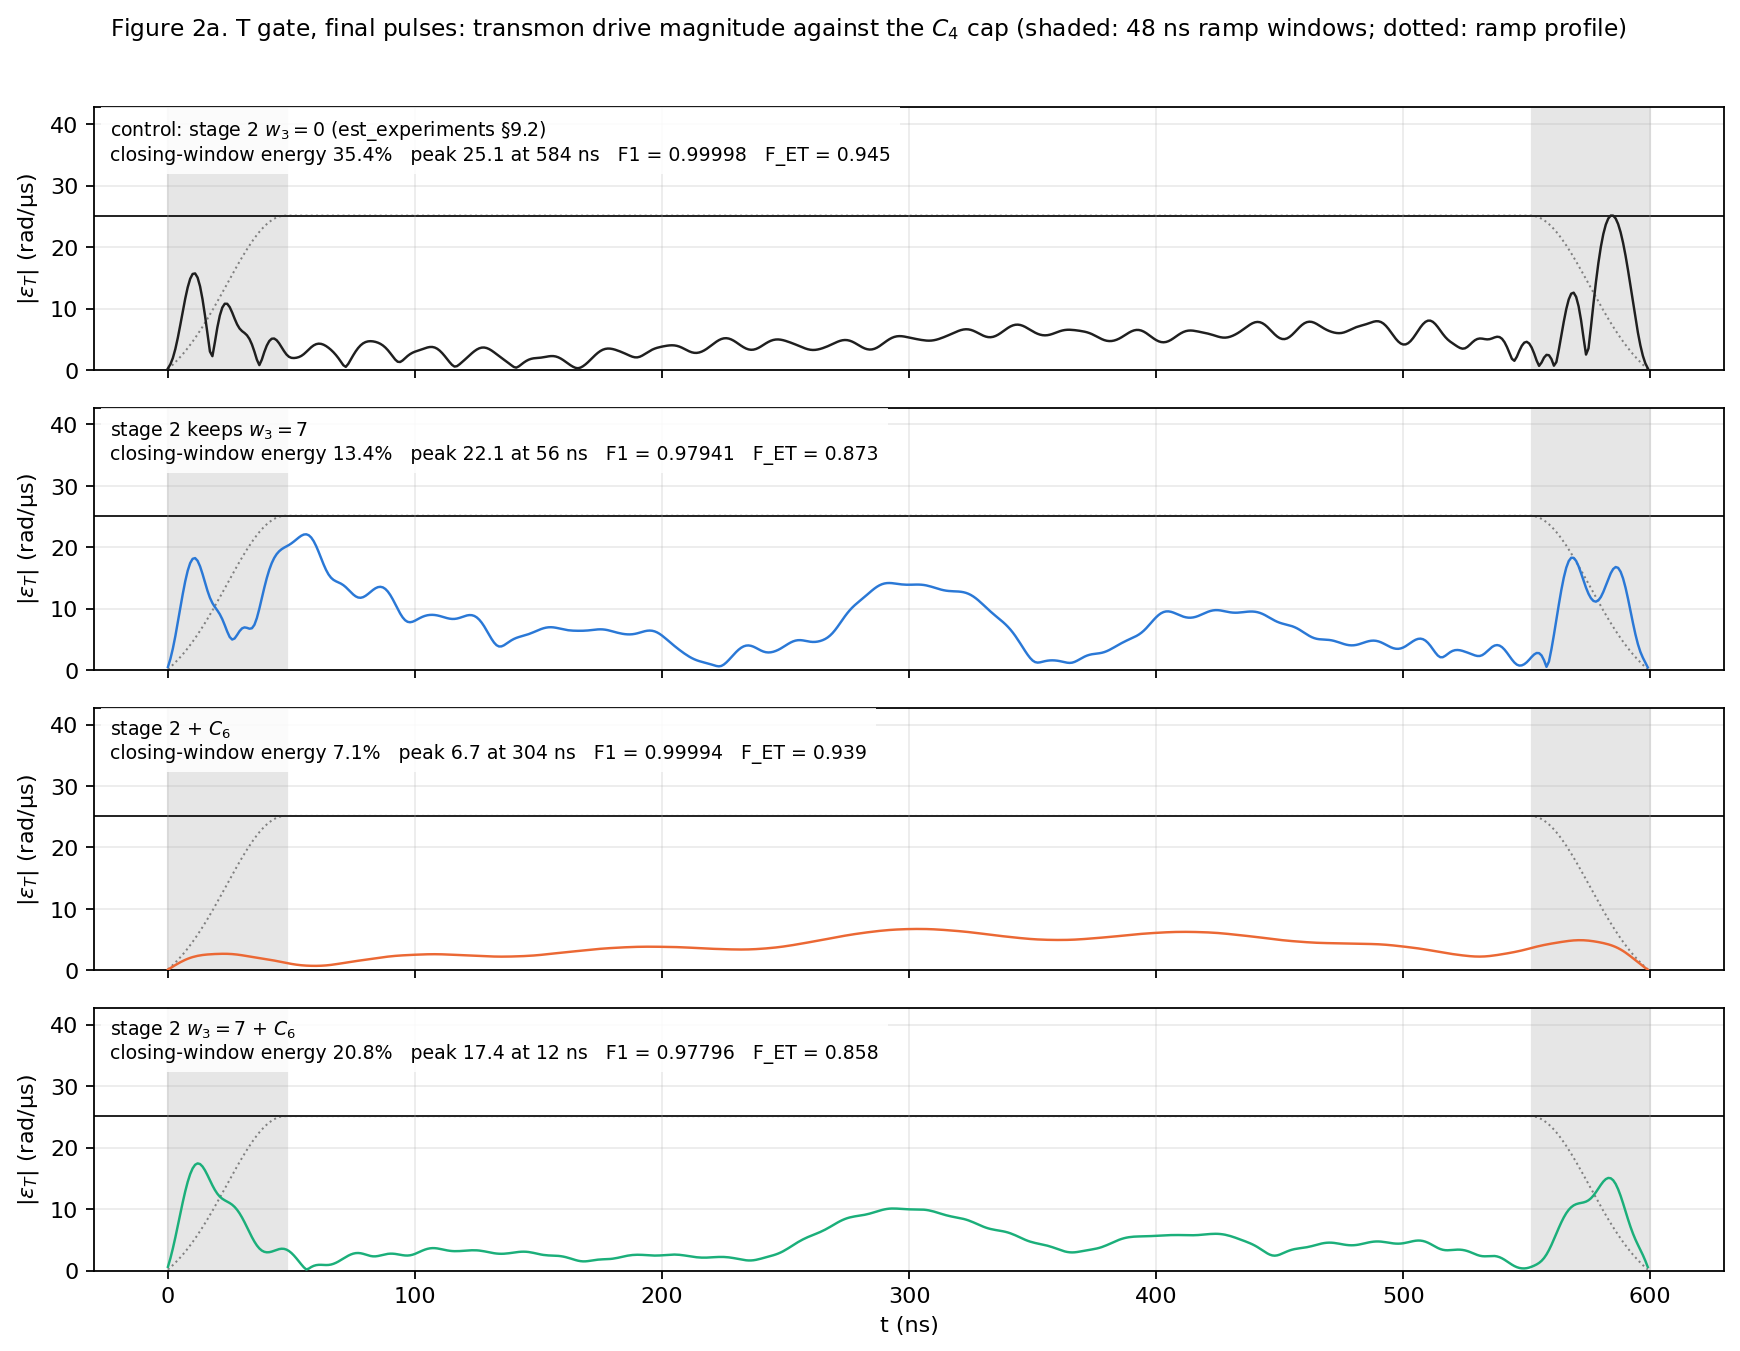

In [8]:
# Figure 2a: the transmon drive magnitude of every final pulse, one row each, same axes.
if s2_have:
    N_RAMP12 = int(round(device.RAMP_NS * 1e-3 / device.DT))
    fig, axes = plt.subplots(len(s2_have), 1, figsize=(11.0, 2.15 * len(s2_have)),
                             sharex=True, sharey=True, squeeze=False)
    for ax, run in zip(axes[:, 0], s2_have):
        eps = s2tr[f"{run}/final/eps_T"]
        N = len(eps)
        t_ns = np.arange(N) * device.DT * 1e3
        T_ns = N * device.DT * 1e3
        for x0, x1 in ((0.0, device.RAMP_NS), (T_ns - device.RAMP_NS, T_ns)):
            ax.axvspan(x0, x1, color="0.9", zorder=0)
        ax.plot(t_ns, device.ramp_envelope(N, device.DT) * device.EPS_MAX, color="0.5", lw=0.9,
                ls=":", zorder=1)
        ax.axhline(device.EPS_MAX, color="0.15", lw=0.9, zorder=1)
        ax.plot(t_ns, eps, color=S2_COLOR[run], lw=1.1, zorder=3)
        r = s2[(s2.run == run) & (s2.stage == "final")].iloc[0]
        ax.text(0.01, 0.96, f"{S2_LABEL[run]}\nclosing-window energy {r.E_ramp_end:.1%}   "
                f"peak {r.peak_eps_T:.1f} at {r.t_peak_ns:.0f} ns   F1 = {r.F1:.5f}   "
                f"F_ET = {r.F_ET:.3f}", transform=ax.transAxes, va="top", fontsize=8.5,
                bbox=dict(facecolor="white", edgecolor="none", alpha=0.85))
        ax.set_ylim(0, device.EPS_MAX * 1.7)
        ax.set_ylabel(r"$|\varepsilon_T|$ (rad/μs)")
        ax.grid(alpha=0.25)
    axes[-1, 0].set_xlabel("t (ns)")
    fig.suptitle("Figure 2a. T gate, final pulses: transmon drive magnitude against the $C_4$ cap "
                 "(shaded: 48 ns ramp windows; dotted: ramp profile)", fontsize=10.5)
    fig.tight_layout(rect=(0, 0, 1, 0.97))
    fig7a_path = os.path.join(FIG_DIR, "fig7a_stage2_waveforms_T.png")
    fig.savefig(fig7a_path, dpi=160, bbox_inches="tight")
    plt.close(fig)
    show(fig7a_path, width=900)

**Figure 2a. Transmon drive magnitude, final pulses.**
- **Control (black):** small and flat mid-gate, then a spike to the cap at 584 ns, with 35.4% of the
  energy in the closing window.
- **`est_d2` (orange) is the only even drive.** Nothing exceeds 6.7 rad/μs, the largest feature is
  mid-gate, and it tapers cleanly into both ramp windows. It puts 7.1% of its energy in a window that is
  8% of the gate. Out-of-band transmon energy falls from 7.5% to 0.016%.
- **Both $w_3 = 7$ runs (blue, green) move the spike rather than remove it.** The peak migrates to the
  opening window (56 ns and 12 ns), and a second burst remains at the end. Their closing-window
  fractions (13.4%, 20.8%) are below the control's only because they never make the final correction:
  see $F_1$.

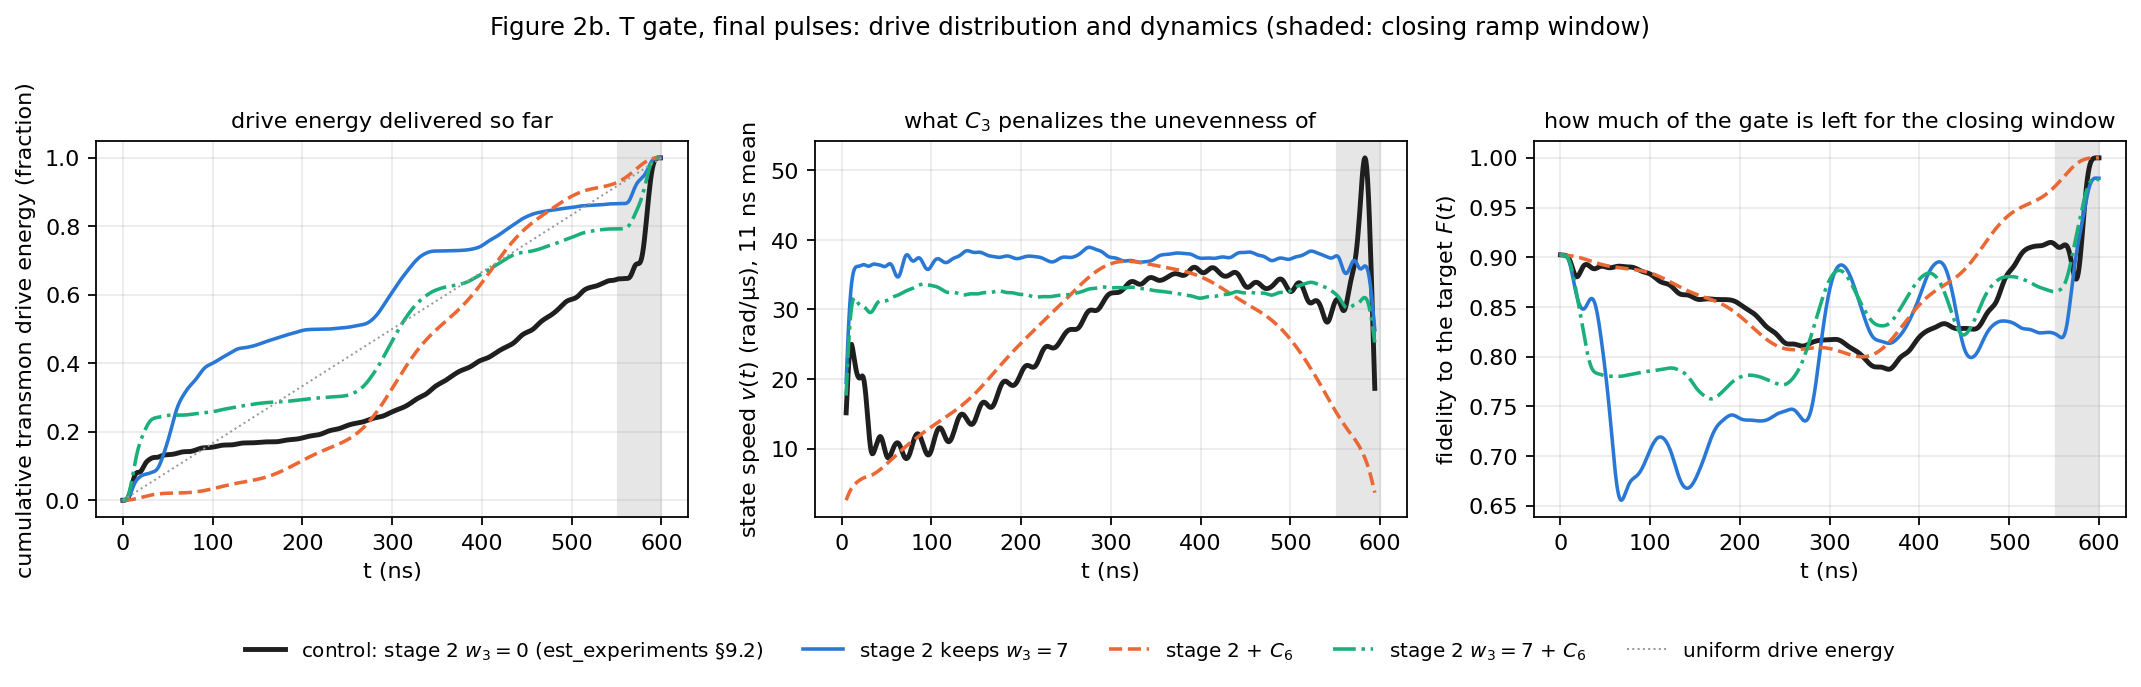

In [9]:
# Figure 2b: when the drive is spent, how fast the state moves, and when the gate is done.
if s2_have:
    fig, axes = plt.subplots(1, 3, figsize=(13.5, 4.0), sharex=True)
    for run in s2_have:
        kw = dict(color=S2_COLOR[run], ls=S2_LS[run], lw=2.2 if run == "control" else 1.6,
                  label=S2_LABEL[run])
        cum = s2tr[f"{run}/final/E_cum"]
        t_ns = np.arange(len(cum)) * device.DT * 1e3
        axes[0].plot(t_ns, cum, **kw)
        v = s2tr[f"{run}/final/v"]
        k = 11                                             # 11 ns running mean, for legibility only
        axes[1].plot(t_ns[k // 2:len(v) - k // 2], np.convolve(v, np.ones(k) / k, mode="valid"), **kw)
        F = s2tr[f"{run}/final/F"]
        axes[2].plot(np.arange(len(F)) * device.DT * 1e3, F, **kw)
    T_ns = len(cum) * device.DT * 1e3
    for ax in axes:
        ax.axvspan(T_ns - device.RAMP_NS, T_ns, color="0.9", zorder=0)
        ax.grid(alpha=0.25)
        ax.set_xlabel("t (ns)")
    axes[0].plot([0, T_ns], [0, 1], color="0.6", lw=0.9, ls=":", label="uniform drive energy")
    axes[0].set_ylabel("cumulative transmon drive energy (fraction)")
    axes[1].set_ylabel("state speed $v(t)$ (rad/μs), 11 ns mean")
    axes[2].set_ylabel("fidelity to the target $F(t)$")
    axes[0].set_title("drive energy delivered so far", fontsize=10)
    axes[1].set_title("what $C_3$ penalizes the unevenness of", fontsize=10)
    axes[2].set_title("how much of the gate is left for the closing window", fontsize=10)
    handles, labels = axes[0].get_legend_handles_labels()
    fig.legend(handles, labels, loc="lower center", ncol=5, frameon=False, fontsize=9,
               bbox_to_anchor=(0.5, -0.06))
    fig.suptitle("Figure 2b. T gate, final pulses: drive distribution and dynamics "
                 "(shaded: closing ramp window)", fontsize=11)
    fig.tight_layout(rect=(0, 0.05, 1, 0.95))
    fig7b_path = os.path.join(FIG_DIR, "fig7b_stage2_distribution_T.png")
    fig.savefig(fig7b_path, dpi=160, bbox_inches="tight")
    plt.close(fig)
    show(fig7b_path, width=900)

**Figure 2b. Energy, speed and progress.**
- **Left:** the control's vertical step in the shaded window is the 35% it delivers in the last 48 ns.
  `est_d2` has the smallest step and follows the uniform diagonal most closely after 300 ns.
- **Middle, the key panel.** $C_3$ does exactly what it is built for: both $w_3 = 7$ runs hold the
  state speed flat at 32–38 rad/μs ($C_3$ = 0.010 and 0.009). `est_d2` has the *least* uniform speed of
  the four ($C_3 = 0.214$, a hump peaking near 300 ns) and the most even drive. **Uniform speed through
  Hilbert space and an even drive are different properties.** On T they pull in opposite directions.
- **Right:** the control is at $F = 0.912$ when the closing window opens and makes up the rest there.
  `est_d2` is already at 0.972 and has climbed steadily since 300 ns. The two $w_3 = 7$ runs dip to
  $F \approx 0.66$ and $0.76$ early on, moving at uniform speed *away* from the target, and never get
  past 0.98.

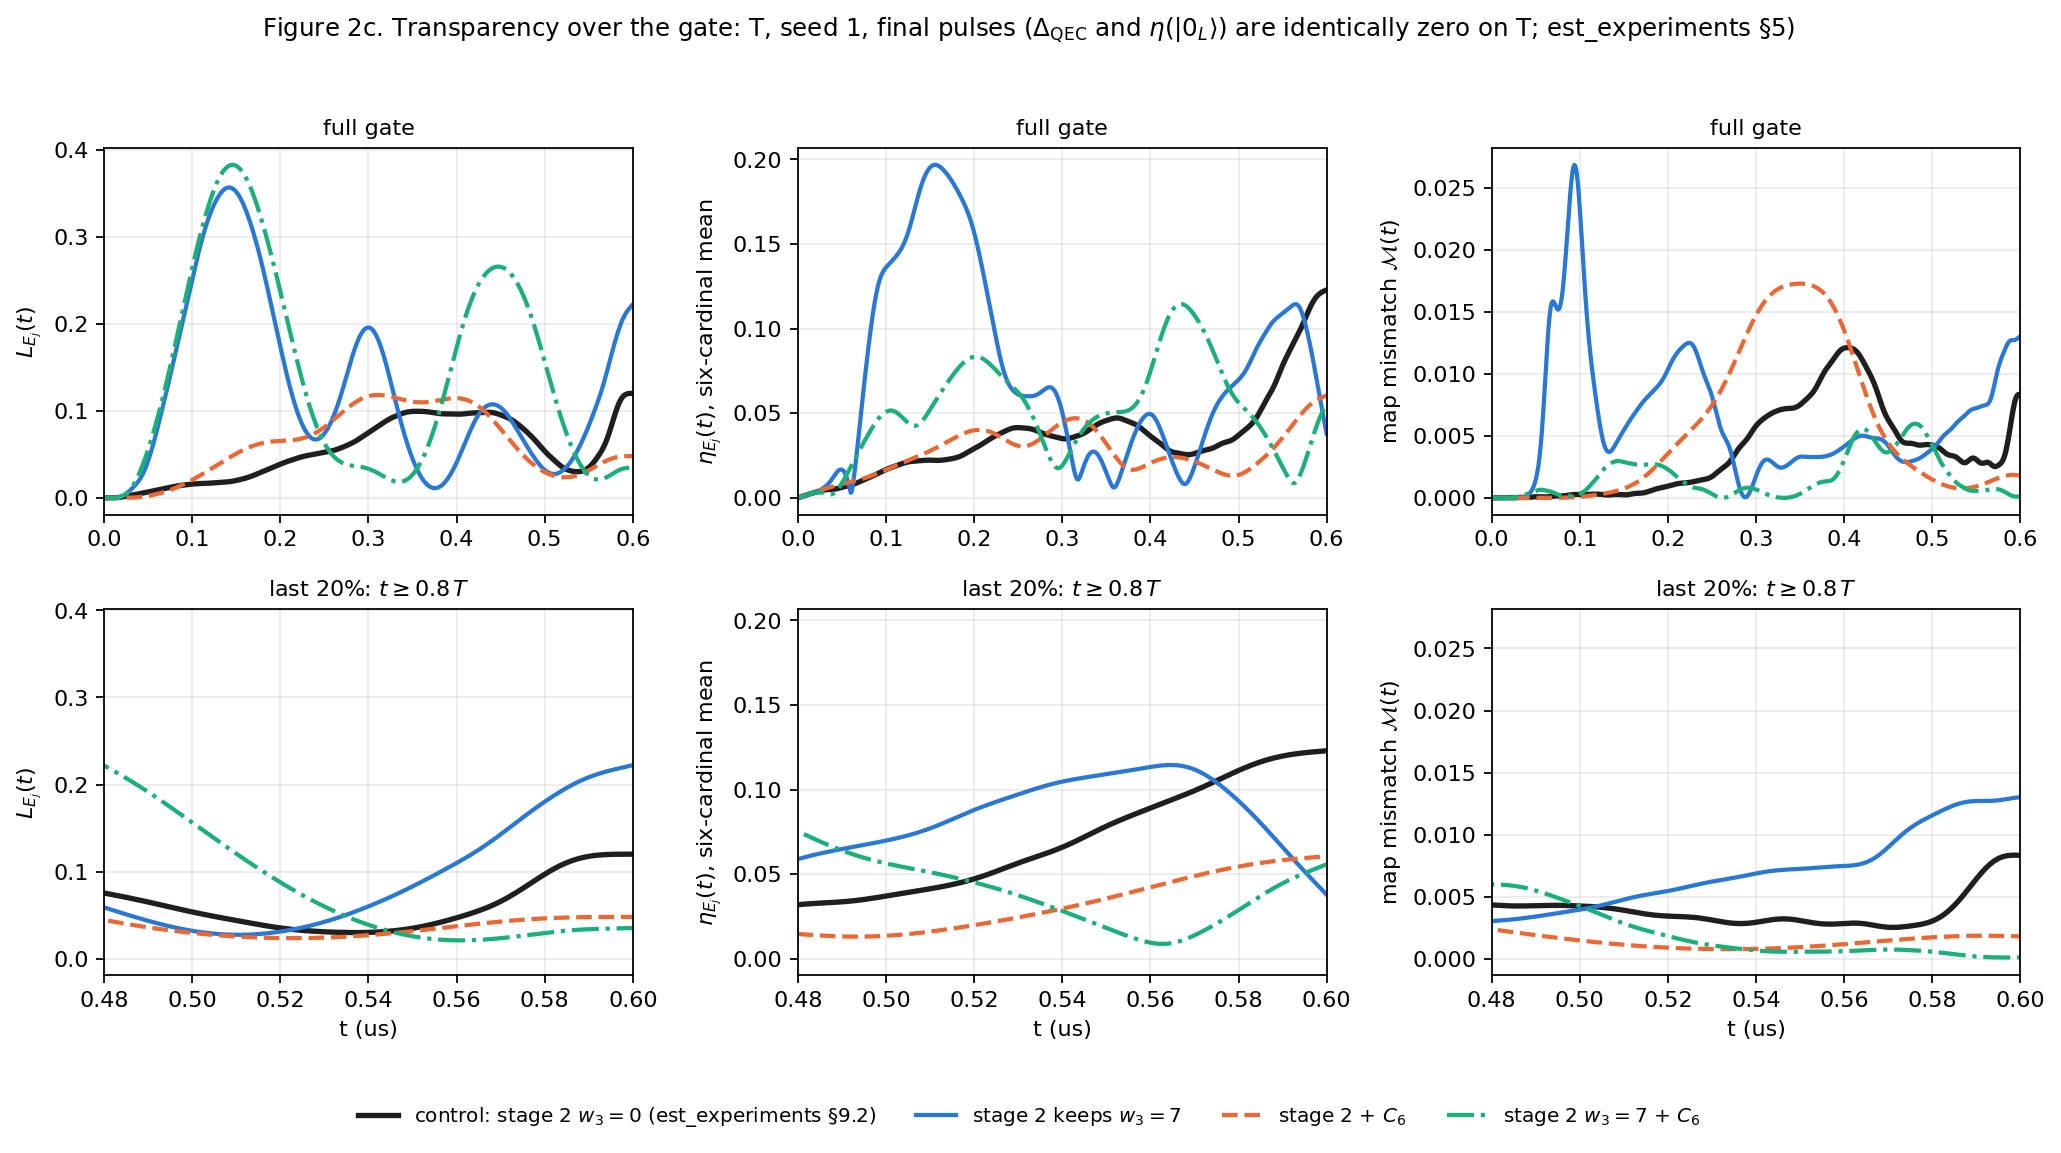

In [10]:
# Figure 2c: the transparency metrics that CAN move on T, over the gate; bottom row zooms to
# the end. Delta_QEC and eta(|0_L>) are machine zero for every T pulse (est_experiments §5), so they are not drawn.
if s2_have:
    TR12 = [("L", r"$L_{E_j}(t)$"), ("eta_avg", r"$\eta_{E_j}(t)$, six-cardinal mean"),
            ("M", r"map mismatch $\mathcal{M}(t)$")]
    fig, axes = plt.subplots(2, 3, figsize=(13.0, 7.0), sharey="col")
    for c, (key, ylab) in enumerate(TR12):
        for r in range(2):
            ax = axes[r, c]
            for run in s2_have:
                y = s2tr[f"{run}/final/{key}"]
                t = np.arange(len(y)) * device.DT
                ax.plot(t, y, color=S2_COLOR[run], ls=S2_LS[run],
                        lw=2.4 if run == "control" else 1.9, label=S2_LABEL[run])
            T = t[-1]
            ax.set_xlim((0.0 if r == 0 else 0.8 * T), T)
            ax.set_ylabel(ylab)
            ax.grid(alpha=0.25)
            ax.set_title(("full gate" if r == 0 else r"last 20%: $t \geq 0.8\,T$"), fontsize=10)
            if r == 1:
                ax.set_xlabel("t (us)")
    handles, labels = axes[0, 0].get_legend_handles_labels()
    fig.legend(handles, labels, loc="lower center", ncol=4, frameon=False, fontsize=9,
               bbox_to_anchor=(0.5, -0.03))
    fig.suptitle("Figure 2c. Transparency over the gate: T, seed 1, final pulses "
                 r"($\Delta_{\rm QEC}$ and $\eta(|0_L\rangle)$ are identically zero on T; est_experiments §5)", fontsize=11)
    fig.tight_layout(rect=(0, 0.04, 1, 0.96))
    fig7c_path = os.path.join(FIG_DIR, "fig7c_stage2_traces_T.png")
    fig.savefig(fig7c_path, dpi=160, bbox_inches="tight")
    plt.close(fig)
    show(fig7c_path, width=900)

**Figure 2c. Transparency over the gate.**
- **At the end (bottom row), `est_d2` beats the control on all three:** $L(T)$ 0.120 → 0.048,
  six-cardinal $\eta(T)$ 0.123 → 0.061, $\mathcal{M}(T)$ $8.3\times10^{-3} \to 1.8\times10^{-3}$. The
  control's rise in $L$ and $\eta$ over the last ~40 ns coincides with its drive spike.
- **Mid-gate it pays a little:** $\mathcal{M}$ peaks at 0.017 near 0.35 μs (control 0.012), and mean
  $L$ rises from 0.054 to 0.061.
- **The $w_3 = 7$ runs leak heavily early** ($L$ peaks at 0.36–0.38 near 0.15 μs), which is their
  time-averaged $F_{\rm ET}$ loss in Table 4. `est_c3s2_d2` finishes with the lowest $L(T)$ (0.035) and
  $\mathcal{M}(T)$ ($10^{-4}$) of any run, but on a pulse that is not the gate ($F_1 = 0.978$).

<a id="2.2"></a>
### 2.2 Results: is the drive still concentrated at $t = T$?

| | control | `est_c3s2` | `est_d2` | `est_c3s2_d2` |
|---|---|---|---|---|
| $F_1$ | 0.99998 | **0.97941** | 0.99994 | **0.97796** |
| stage-2 stop | maxiter | maxiter | pgtol (343 it) | maxiter |
| drive energy in the closing 48 ns | 35.4% | 13.4% | **7.1%** | 20.8% |
| peak $\lvert\varepsilon_T\rvert$ (rad/μs) | 25.1 at 584 ns | 22.1 at 56 ns | **6.7 at 304 ns** | 17.4 at 12 ns |
| $C_6$ | 526 | 428 | **34** | 127 |
| $C_3$ (speed unevenness) | 0.202 | 0.010 | 0.214 | 0.009 |
| $F_{\rm ET}$ | **0.945** | 0.873 | 0.939 | 0.858 |
| $L$ mean / at $T$ | **0.054** / 0.120 | 0.125 / 0.222 | 0.061 / 0.048 | 0.141 / 0.035 |
| six-cardinal $\eta$ mean / at $T$ | 0.036 / 0.123 | 0.074 / 0.038 | **0.027** / 0.061 | 0.051 / 0.056 |
| $\mathcal{M}$ mean / at $T$ | $3.7\times10^{-3}$ / $8.3\times10^{-3}$ | $6.4\times10^{-3}$ / $1.3\times10^{-2}$ | $5.4\times10^{-3}$ / $1.8\times10^{-3}$ | $1.7\times10^{-3}$ / $9.9\times10^{-5}$ |
| $F_{\rm err}(T)$ | 0.874 | 0.778 | 0.950 | 0.953 |
| transmon out-of-band fraction | 7.5% | 1.7% | **0.016%** | 1.2% |
| transmon pre-image entries at the box | 55 | 227 | **0** | 104 |

**Table 5. The answer in one table** (final pulses, $n_c = 20$, eigh propagator; Table 4 has the rest).
Bold marks the best among the runs that reach the gate ($F_1 \ge 0.9999$).

1. **Stage-2 $C_6$ ($w_6 = 10^{-4}$) evens out the drive and keeps the gate.** The end spike is gone,
   the largest drive is 27% of the cap and sits mid-gate, and stage 2 converges on gradient tolerance
   rather than running out of iterations. The pulse is also *more* transparent at the end: $L(T)$ is 2.5×
   lower, $\mathcal{M}(T)$ 4.6× lower, and $F_{\rm err}(T)$ rises from 0.874 to 0.950. So the closing spike
   was not a harmless correction; it was where the control's end-of-gate leak came from. The price is
   $F_1$ 0.99998 → 0.99994 and $F_{\rm ET}$ 0.945 → 0.939.
2. **Keeping $w_3 = 7$ in stage 2 does not produce a gate.** $7 \times C_3 \approx 0.072$ outweighs
   everything stage 2 can trade against it, so stage 2 barely moves off stage 1 ($C_1$ 0.034 → 0.021)
   and stops on `maxiter`. The drive is not evened out but re-concentrated at the start: the peak is at
   56 ns, with 40% of the energy in the first 100 ns. Every time-averaged transparency metric gets worse.
3. **Both together inherits that failure.** Adding $C_6$ cuts $C_6$ 3.4× against `est_c3s2` and gives
   the best endpoint numbers of any run, but at $F_1 = 0.978$.
4. **Why $C_3$ could not help.** It holds the *state speed* uniform, and it succeeds (Figure 2b,
   middle), yet the pulse with the least uniform speed has the most even drive. Uniform motion through
   Hilbert space is a property of the trajectory, not of the waveform.

<a id="2.3"></a>
### 2.3 Caveats

- **Single seed (1), single gate.**
- **$w_3 = 7$ is negative at this weight only.** A smaller stage-2 $w_3$ was not tried and might
  finish the gate.
- **$w_6 = 10^{-4}$ is the top of the pre-set grid.** All three screened weights passed, so a larger one
  may pass too. The grid was not widened after the results.
  - The choice is robust to the stage-1 budget: the 500-it screen and the 2000-it run reach the same
    drive distribution (7.2% vs 7.1% closing-window energy, peak 6.74 at 304 ns in both) from stage-1
    pulses 52% apart.
- **The control and the shared stage 1 are box-constrained.** Their raw pre-images have 55 and 127
  transmon entries pinned at `hard_bound = 60`, against none for `est_d2`. $C_4$ caps the physical
  amplitude either way, but the control is a box-constrained optimum. Part of `est_d2`'s gain may be
  $C_6$ pulling the pre-image off the box.
- **The two $w_3 = 7$ runs stopped on `maxiter`.** Their numbers are where L-BFGS-B was at 2000
  iterations, not converged values.
- **$C_3$ is the repo's normalized form** ([est_experiments §2.1](est_experiments.ipynb#2.1)). The printed form is either inert or favours
  parking, and was not used.
- **$\Delta_{\rm QEC}$ and $\eta(|0_L\rangle)$ are not reported**, because they are identically zero on T
  ([est_experiments §5](est_experiments.ipynb#5)).
- **Nothing was promoted.** The new pulses are
  `pulses/est/{u,x}_T_est_{c3s2,d2,c3s2_d2}_best2000[_stage1|_stage2].npy`. `u_T_est.npy` and
  `u_T_est_best2000.npy` are unchanged, and `est_d2` has not been given any delivered-pulse name.

---

**Notebook complete.** Nothing under `EST/`, `core/`, `pulses/` or `logs/` is modified by this
notebook; every pulse it reads is written by `EST/train_est_eigh.py`, not by any cell.

[§1](#1) draws `figures/est/fig6{a,b,c,d}_newterms_*_X.png` (Figures 1a–d) and, through
`EST/compare_new_terms.py`, regenerates `tables/est_newterms_X_seed6.csv` and
`tables/est_newterms_X_seed6_traces.npz`. Its training runs are CLI, not notebook:
- **The weight scan** (Figure 1a): X, 500 it/stage, seeds 0, 2, 4, 5, 6, 8, 54 runs of which
  seed 6's six original runs are reused. `python EST/smoke_new_terms.py commands > scan.sh && sh scan.sh`,
  then `python EST/smoke_new_terms.py summarize` -> `tables/est_newterms_smoke_X_6seeds.csv`. The
  original seed-6-only table, `tables/est_newterms_smoke_X_seed6.csv`, is kept frozen.
- **The four full runs** (Figures 1b–d, Table 2): seed 6, 2000 it/stage, the loop in [§1.1](#1.1),
  then `python EST/compare_new_terms.py`.

[§2](#2) regenerates `figures/est/fig7{a,b,c}_stage2_*_T.png` (Figures 2a–c),
`tables/est_stage2_T_seed1.csv`, `tables/est_stage2_T_seed1_scan.csv` and
`tables/est_stage2_T_seed1_traces.npz` through `EST/stage2_t.py`. Its seven training runs (three
500-it/stage screens, three 2000-it/stage configs, and [est_experiments §9.2](est_experiments.ipynb#9.2)'s
control) are written by `EST/train_est_eigh.py`, not by any cell; `python EST/stage2_t.py commands`
prints them. The full runs took 0.3–0.5 h each, three at a time.